# Replication: Pass-through of Emissions Costs in Electricity Markets

## Fabra, N., & Reguant, M. (2014). American Economic Review, 104(9), 2872-2899

This notebook replicates the analysis from the paper examining how EU-ETS carbon prices affected Spanish electricity market prices during 2004-2007.

### Overview
1. **Data Processing**: Load and clean bidding data from the Spanish electricity market
2. **Preliminary Analysis**: Visualize CO2 prices, electricity prices, and emissions rates
3. **Pass-through Regressions**: IV estimation of cost pass-through using carbon prices as instruments
4. **Structural Analysis**: Test for internalization of emissions costs
5. **Market Clearing**: Python implementation of the MATLAB market clearing algorithm
6. **Elasticity Analysis**: Estimate residual demand slopes and firm-level elasticities

## Section 1: Setup Environment and Global Paths

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import linprog
from scipy.stats import norm
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Define global paths
DIRPATH = '/Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data'
STATA_DATA = os.path.join(DIRPATH, 'stata_data')
MATLAB_DATA = os.path.join(DIRPATH, 'matlab_data')
FIGURES = os.path.join(DIRPATH, 'figures')
TABLES = os.path.join(DIRPATH, 'tables')

# Create figures directory if it doesn't exist
os.makedirs(FIGURES, exist_ok=True)

print("=" * 70)
print("REPLICATION: Pass-through of Emissions Costs in Electricity Markets")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 70)
print(f"\nData directory: {DIRPATH}")
print(f"Stata data: {STATA_DATA}")
print(f"MATLAB data: {MATLAB_DATA}")

REPLICATION: Pass-through of Emissions Costs in Electricity Markets
Fabra & Reguant (2014), American Economic Review

Data directory: /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data
Stata data: /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/stata_data
MATLAB data: /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/matlab_data


In [3]:
# Check available data files
print("\n" + "=" * 70)
print("AVAILABLE DATA FILES")
print("=" * 70)

# Stata data files
print("\n📁 Stata Data Files (.dta):")
dta_files = glob.glob(os.path.join(STATA_DATA, '*.dta'))
for f in sorted(dta_files):
    size = os.path.getsize(f) / (1024 * 1024)
    print(f"   • {os.path.basename(f)} ({size:.2f} MB)")

# MATLAB data files
print("\n📁 MATLAB Data Files (.csv):")
csv_files = glob.glob(os.path.join(MATLAB_DATA, '*.csv'))
for f in sorted(csv_files)[:10]:
    print(f"   • {os.path.basename(f)}")
if len(csv_files) > 10:
    print(f"   ... and {len(csv_files) - 10} more files")


AVAILABLE DATA FILES

📁 Stata Data Files (.dta):
   • data_eua_prices.dta (0.07 MB)
   • data_regressions_lite.dta (85.59 MB)
   • data_regressions_passthrough.dta (6.62 MB)
   • data_regressions_structural.dta (1.24 MB)
   • passthrough_results.dta (4.80 MB)

📁 MATLAB Data Files (.csv):
   • data_20050601.csv
   • data_20050602.csv
   • data_20050603.csv
   • data_20050604.csv
   • data_20050605.csv
   • data_20050606.csv
   • data_20050607.csv
   • data_20050608.csv
   • data_20050609.csv
   • data_20050610.csv
   ... and 21 more files


## Section 2: Load Stata Data Files

Since the raw data processing requires access to the original Spanish market operator files (not included in the replication package), we work with the pre-processed Stata datasets provided.

In [4]:
# Function to read Stata files safely
def read_stata_safe(filepath):
    """Read Stata file with error handling"""
    try:
        return pd.read_stata(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

# Load main datasets
print("\n" + "=" * 70)
print("LOADING STATA DATASETS")
print("=" * 70)

# 1. Passthrough regression data
print("\n📊 Loading data_regressions_passthrough.dta...")
data_passthrough = read_stata_safe(os.path.join(STATA_DATA, 'data_regressions_passthrough.dta'))
if data_passthrough is not None:
    print(f"   Shape: {data_passthrough.shape}")
    print(f"   Columns: {list(data_passthrough.columns[:15])}...")

# 2. Structural regression data
print("\n📊 Loading data_regressions_structural.dta...")
data_structural = read_stata_safe(os.path.join(STATA_DATA, 'data_regressions_structural.dta'))
if data_structural is not None:
    print(f"   Shape: {data_structural.shape}")

# 3. EUA prices
print("\n📊 Loading data_eua_prices.dta...")
data_eua = read_stata_safe(os.path.join(STATA_DATA, 'data_eua_prices.dta'))
if data_eua is not None:
    print(f"   Shape: {data_eua.shape}")

# 4. Lite regression data (for rigidities analysis)
print("\n📊 Loading data_regressions_lite.dta...")
data_lite = read_stata_safe(os.path.join(STATA_DATA, 'data_regressions_lite.dta'))
if data_lite is not None:
    print(f"   Shape: {data_lite.shape}")

# 5. Passthrough results from MATLAB
print("\n📊 Loading passthrough_results.dta...")
data_matlab = read_stata_safe(os.path.join(STATA_DATA, 'passthrough_results.dta'))
if data_matlab is not None:
    print(f"   Shape: {data_matlab.shape}")


LOADING STATA DATASETS

📊 Loading data_regressions_passthrough.dta...
   Shape: (30648, 45)
   Columns: ['year', 'month', 'day', 'hour', 'mg_price', 'eprice', 'coal', 'gas', 'brent', 'totalcost', 'totalcost2', 'ecost', 'ecost2', 'erate', 'time']...

📊 Loading data_regressions_structural.dta...
   Shape: (9349, 25)

📊 Loading data_eua_prices.dta...
   Shape: (2191, 4)

📊 Loading data_regressions_lite.dta...
   Shape: (1081264, 19)

📊 Loading passthrough_results.dta...
   Shape: (18960, 38)


In [5]:
# Examine passthrough regression data structure
if data_passthrough is not None:
    print("\n" + "=" * 70)
    print("DATA STRUCTURE: data_regressions_passthrough.dta")
    print("=" * 70)
    print("\nVariables:")
    for col in data_passthrough.columns:
        dtype = data_passthrough[col].dtype
        non_null = data_passthrough[col].notna().sum()
        print(f"   • {col}: {dtype} (N={non_null})")
    
    print("\n\nSample observations:")
    display(data_passthrough.head(10))


DATA STRUCTURE: data_regressions_passthrough.dta

Variables:
   • year: float64 (N=30648)
   • month: float64 (N=30648)
   • day: float64 (N=30648)
   • hour: int8 (N=30648)
   • mg_price: float64 (N=30648)
   • eprice: float64 (N=30432)
   • coal: float64 (N=30648)
   • gas: float64 (N=30648)
   • brent: float64 (N=30648)
   • totalcost: float32 (N=17416)
   • totalcost2: float32 (N=23031)
   • ecost: float32 (N=22105)
   • ecost2: float32 (N=26050)
   • erate: float32 (N=23185)
   • time: float32 (N=30648)
   • weekd: int8 (N=30648)
   • peak: float32 (N=30648)
   • rd: float32 (N=30648)
   • temp: float64 (N=30648)
   • tempx: float64 (N=30648)
   • humid: float64 (N=30648)
   • windx: float64 (N=30648)
   • coal2: float32 (N=30648)
   • gas2: float32 (N=30648)
   • brent2: float32 (N=30648)
   • lcoal: float32 (N=30648)
   • lgas: float32 (N=30648)
   • lbrent: float32 (N=30648)
   • temp2: float32 (N=30648)
   • windx2: float32 (N=30648)
   • windtime: float32 (N=30648)
   • ecos

,year,month,day,hour,mg_price,eprice,coal,gas,brent,totalcost,totalcost2,ecost,ecost2,erate,time,weekd,peak,rd,temp,tempx,humid,windx,coal2,gas2,brent2,lcoal,lgas,lbrent,temp2,windx2,windtime,ecost_int,leprice,lmg_price,ym,yb,yq,totalcost2_peak,totalcost2_off,ltotalcost2_peak,ltotalcost2_off,ecost2_peak,ecost2_off,lecost2_peak,lecost2_off
0,2004.0000,1.0000,1.0000,1,28.9900,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,1.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0007,0.0000,0.0000,3.4009,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
1,2004.0000,1.0000,1.0000,2,28.2300,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,2.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0013,0.0000,0.0000,3.3752,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
2,2004.0000,1.0000,1.0000,3,25.4800,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,3.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0020,0.0000,0.0000,3.2764,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
3,2004.0000,1.0000,1.0000,4,23.0000,0.0000,0.6668,1.3055,1.7566,NaN,19.8138,0.0000,0.0000,1.0251,4.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0026,0.0000,0.0000,3.1781,1.0000,1.0000,1.0000,0.0000,19.8138,0.0000,3.0356,0.0000,0.0000,0.0000,0.0000
4,2004.0000,1.0000,1.0000,5,16.5400,0.0000,0.6668,1.3055,1.7566,20.1586,20.1586,0.0000,0.0000,0.9563,5.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0033,0.0000,0.0000,2.8645,1.0000,1.0000,1.0000,0.0000,20.1586,0.0000,3.0520,0.0000,0.0000,0.0000,0.0000
5,2004.0000,1.0000,1.0000,6,14.6800,0.0000,0.6668,1.3055,1.7566,NaN,20.6760,0.0000,0.0000,0.9362,6.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0039,0.0000,0.0000,2.7524,1.0000,1.0000,1.0000,0.0000,20.6760,0.0000,3.0762,0.0000,0.0000,0.0000,0.0000
6,2004.0000,1.0000,1.0000,7,14.5400,0.0000,0.6668,1.3055,1.7566,21.0754,21.0754,0.0000,0.0000,0.9406,7.0000,4,0.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0046,0.0000,0.0000,2.7434,1.0000,1.0000,1.0000,0.0000,21.0754,0.0000,3.0945,0.0000,0.0000,0.0000,0.0000
7,2004.0000,1.0000,1.0000,8,11.6700,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,8.0000,4,1.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0052,0.0000,0.0000,2.5392,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
8,2004.0000,1.0000,1.0000,9,7.5700,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,9.0000,4,1.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0059,0.0000,0.0000,2.1483,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
9,2004.0000,1.0000,1.0000,10,2.8700,0.0000,0.6668,1.3055,1.7566,NaN,NaN,0.0000,0.0000,NaN,10.0000,4,1.0000,0.0000,7.9655,18.5800,83.5750,6.5606,0.4446,1.7043,3.0856,0.5109,0.8353,1.0140,63.4492,43.0418,0.0066,0.0000,0.0000,1.3533,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000


## Section 3: Preliminary Graphs - CO2 and Electricity Prices

Following `prelim_graphs.do`, we visualize the relationship between CO2 prices and electricity prices during the EU-ETS trial period.


FIGURE: CO2 Prices and Electricity Prices (2004-2006)

Available columns: ['year', 'month', 'day', 'eprice', 'mg_price']

Daily observations: 1277
Date range: 2004-01-01 00:00:00 to 2007-06-30 00:00:00
Reduced sample observations: 790


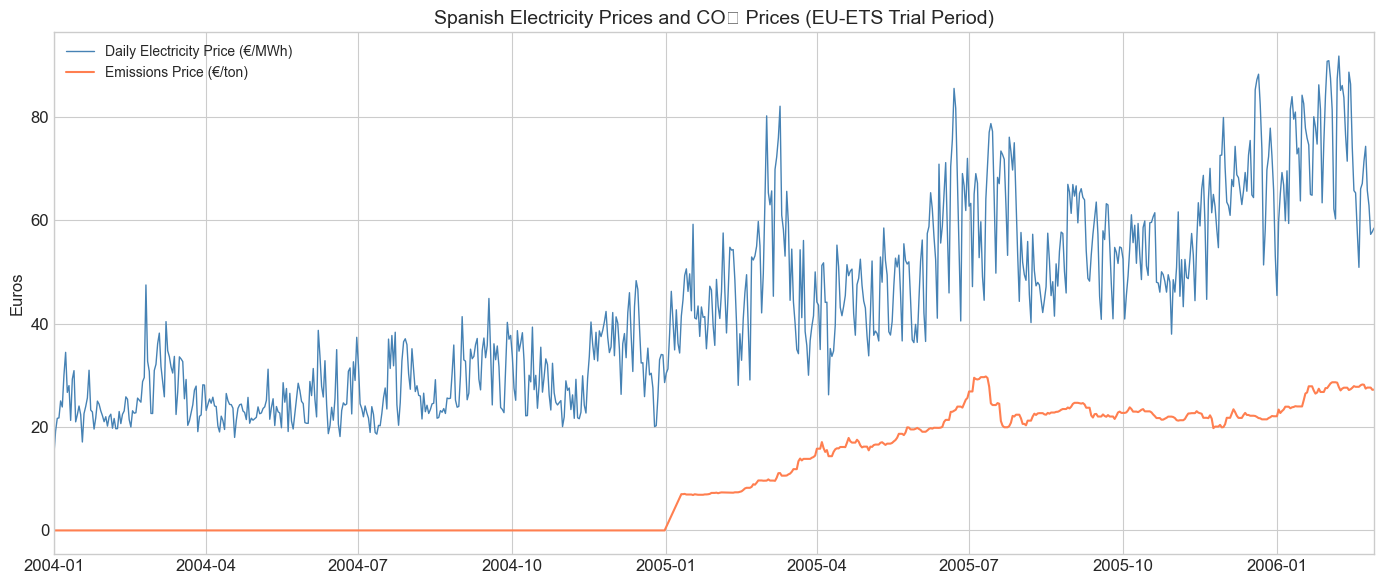


✓ Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures


In [6]:
# Replicate prelim_graphs.do: CO2 prices during the EU-ETS Trial Period
print("\n" + "=" * 70)
print("FIGURE: CO2 Prices and Electricity Prices (2004-2006)")
print("=" * 70)

if data_passthrough is not None:
    # Get required columns
    cols_needed = ['year', 'month', 'day', 'eprice', 'mg_price']
    
    # Check which columns exist
    available_cols = [c for c in cols_needed if c in data_passthrough.columns]
    print(f"\nAvailable columns: {available_cols}")
    
    if len(available_cols) >= 3:
        # Create daily data
        df_prices = data_passthrough[available_cols].copy()
        df_prices = df_prices.drop_duplicates()
        
        # Filter sample period
        df_prices = df_prices[
            (df_prices['year'] >= 2004) & 
            (df_prices['year'] <= 2007)
        ]
        if 'month' in df_prices.columns:
            df_prices = df_prices[~((df_prices['year'] == 2007) & (df_prices['month'] > 6))]
        
        # Create date column
        df_prices['date'] = pd.to_datetime(
            df_prices[['year', 'month', 'day']]
        )
        
        # Collapse to daily averages
        daily_prices = df_prices.groupby('date').agg({
            'eprice': 'mean',
            'mg_price': ['mean', 'max', 'min']
        }).reset_index()
        daily_prices.columns = ['date', 'eprice', 'mg_price', 'max_price', 'min_price']
        
        print(f"\nDaily observations: {len(daily_prices)}")
        print(f"Date range: {daily_prices['date'].min()} to {daily_prices['date'].max()}")
        
        # Filter to reduced sample (before March 2006)
        reduced_sample = daily_prices[
            (daily_prices['date'] < '2006-03-01')
        ].copy()
        
        # Interpolate missing emissions prices to connect the line
        reduced_sample['eprice'] = reduced_sample['eprice'].interpolate(method='linear')
        
        print(f"Reduced sample observations: {len(reduced_sample)}")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 6))
        
        ax.plot(reduced_sample['date'], reduced_sample['mg_price'], 
                label='Daily Electricity Price (€/MWh)', color='steelblue', linewidth=1)
        ax.plot(reduced_sample['date'], reduced_sample['eprice'], 
                label='Emissions Price (€/ton)', color='coral', linewidth=1.5)
        
        ax.set_xlabel('')
        ax.set_ylabel('Euros', fontsize=12)
        ax.legend(loc='upper left', fontsize=10)
        ax.set_title('Spanish Electricity Prices and CO₂ Prices (EU-ETS Trial Period)', fontsize=14)
        
        # Format x-axis
        ax.set_xlim(reduced_sample['date'].min(), reduced_sample['date'].max())
        
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES, 'prices_sample_reduced_python.pdf'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(FIGURES, 'prices_sample_reduced_python.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Figure saved to {FIGURES}")
    else:
        print("Missing required columns for price plot")

## Section 4: Marginal Emissions Rate by Hour of Day

Analyzing how the marginal emissions rate varies by hour - reflecting the changing marginal technology throughout the day.


FIGURE: Marginal Emissions Rate by Hour of Day

Observations: 11985
Hour range: 1 to 24
Emissions rate range: 0.343 to 1.303


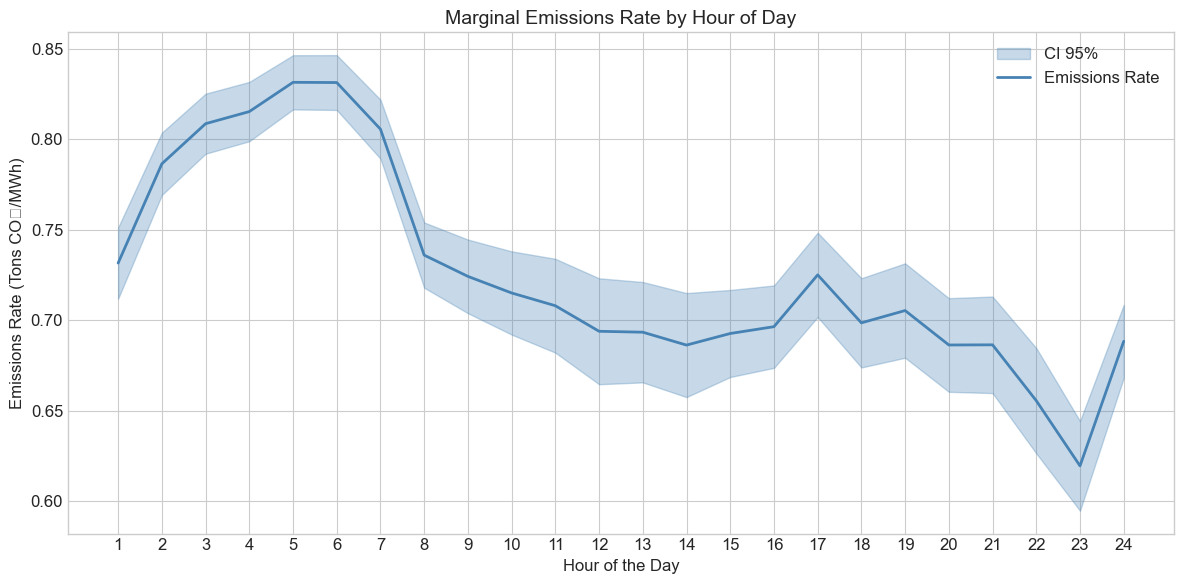


✓ Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures

Hourly Emissions Rate Summary:
 hour   mean    std  count
    1 0.7316 0.2350    547
    2 0.7864 0.2177    615
    3 0.8086 0.2161    651
    4 0.8153 0.2127    646
    5 0.8315 0.1945    647
    6 0.8314 0.1989    661
    7 0.8056 0.2119    647
    8 0.7360 0.2303    626
    9 0.7242 0.2351    513
   10 0.7150 0.2493    451
   11 0.7080 0.2577    379
   12 0.6939 0.2651    315
   13 0.6933 0.2603    338
   14 0.6862 0.2718    343
   15 0.6926 0.2567    437
   16 0.6964 0.2503    464
   17 0.7250 0.2531    453
   18 0.6985 0.2567    416
   19 0.7053 0.2582    376
   20 0.6863 0.2519    364
   21 0.6864 0.2500    337
   22 0.6555 0.2629    313
   23 0.6194 0.2482    385
   24 0.6883 0.2340    519


In [7]:
# Replicate prelim_graphs.do: Marginal emissions rate by hour
print("\n" + "=" * 70)
print("FIGURE: Marginal Emissions Rate by Hour of Day")
print("=" * 70)

if data_passthrough is not None:
    # Check for required columns
    if 'erate' in data_passthrough.columns and 'hour' in data_passthrough.columns:
        # Filter to sample period
        df_erate = data_passthrough[['year', 'month', 'hour', 'erate']].copy()
        df_erate = df_erate[
            (df_erate['year'] < 2006) | 
            ((df_erate['year'] == 2006) & (df_erate['month'] <= 2))
        ]
        df_erate = df_erate.drop_duplicates()
        
        print(f"\nObservations: {len(df_erate)}")
        print(f"Hour range: {df_erate['hour'].min()} to {df_erate['hour'].max()}")
        print(f"Emissions rate range: {df_erate['erate'].min():.3f} to {df_erate['erate'].max():.3f}")
        
        # Calculate statistics by hour
        hourly_stats = df_erate.groupby('hour')['erate'].agg(['mean', 'std', 'count']).reset_index()
        hourly_stats['se'] = hourly_stats['std'] / np.sqrt(hourly_stats['count'])
        hourly_stats['ci_lower'] = hourly_stats['mean'] - 1.96 * hourly_stats['se']
        hourly_stats['ci_upper'] = hourly_stats['mean'] + 1.96 * hourly_stats['se']
        
        # Create figure with local polynomial smoothing (using moving average approximation)
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Plot CI band
        ax.fill_between(hourly_stats['hour'], 
                       hourly_stats['ci_lower'], 
                       hourly_stats['ci_upper'],
                       alpha=0.3, color='steelblue', label='CI 95%')
        
        # Plot mean line
        ax.plot(hourly_stats['hour'], hourly_stats['mean'], 
                color='steelblue', linewidth=2, label='Emissions Rate')
        
        ax.set_xlabel('Hour of the Day', fontsize=12)
        ax.set_ylabel('Emissions Rate (Tons CO₂/MWh)', fontsize=12)
        ax.set_xticks(range(1, 25))
        ax.legend(loc='upper right')
        ax.set_title('Marginal Emissions Rate by Hour of Day', fontsize=14)
        
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES, 'erate_hour_python.pdf'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(FIGURES, 'erate_hour_python.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Figure saved to {FIGURES}")
        
        # Print summary statistics
        print("\nHourly Emissions Rate Summary:")
        print(hourly_stats[['hour', 'mean', 'std', 'count']].to_string(index=False))
    else:
        print("Missing 'erate' or 'hour' columns")

## Table 1 - Replication : Pass-through Regression Analysis

Replicating `analysis_passthrough_rf.do`: IV estimation of cost pass-through using emissions prices as instruments for marginal emissions costs.

**Main Specification:**
$$\text{Price}_{t} = \alpha + \rho \cdot \text{MarginalEmissionsCost}_{t} + X_{t}'\beta + \varepsilon_{t}$$

Where $\text{MarginalEmissionsCost}_{t} = \text{EmissionsRate}_{t} \times \text{EmissionsPrice}_{t}$ is instrumented by $\text{EmissionsPrice}_{t}$.

In [8]:
# Install linearmodels for IV regression if needed
try:
    from linearmodels.iv import IV2SLS
    print("✓ linearmodels package available")
except ImportError:
    print("Installing linearmodels package...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'linearmodels', '-q'])
    from linearmodels.iv import IV2SLS
    print("✓ linearmodels package installed")

import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from linearmodels.iv import IV2SLS

✓ linearmodels package available


In [9]:
# Prepare data for pass-through regressions
print("\n" + "=" * 70)
print("PASS-THROUGH REGRESSION ANALYSIS")
print("=" * 70)

if data_passthrough is not None:
    # Examine available variables
    print("\nAvailable variables in passthrough dataset:")
    print(list(data_passthrough.columns))
    
    # Key variables we need:
    # mg_price: Market clearing price (dependent variable)
    # ecost2: Marginal emissions cost (endogenous variable) = erate * eprice
    # eprice: Emissions price (instrument)
    # Controls: temp, tempx, humid, windx, coal, gas, brent, etc.
    
    # Check what we have
    key_vars = ['mg_price', 'eprice', 'erate', 'temp', 'windx', 'coal', 'gas', 'brent', 
                'year', 'month', 'hour', 'weekd', 'rd']
    
    available_key = [v for v in key_vars if v in data_passthrough.columns]
    print(f"\nKey variables available: {available_key}")
    
    # Create regression dataset
    df_reg = data_passthrough.copy()
    
    # Generate emission cost variable if not present
    if 'ecost2' not in df_reg.columns:
        if 'erate' in df_reg.columns and 'eprice' in df_reg.columns:
            df_reg['ecost2'] = df_reg['erate'] * df_reg['eprice']
            print("\n✓ Created ecost2 = erate * eprice")
    
    # Check sample restrictions
    if 'rd' in df_reg.columns:
        print(f"\nRoyal Decree observations (rd=1): {(df_reg['rd'] == 1).sum()}")
        df_reg_base = df_reg[df_reg['rd'] != 1].copy()  # Exclude royal decree period
    else:
        df_reg_base = df_reg.copy()
    
    print(f"Observations in baseline sample: {len(df_reg_base)}")


PASS-THROUGH REGRESSION ANALYSIS

Available variables in passthrough dataset:
['year', 'month', 'day', 'hour', 'mg_price', 'eprice', 'coal', 'gas', 'brent', 'totalcost', 'totalcost2', 'ecost', 'ecost2', 'erate', 'time', 'weekd', 'peak', 'rd', 'temp', 'tempx', 'humid', 'windx', 'coal2', 'gas2', 'brent2', 'lcoal', 'lgas', 'lbrent', 'temp2', 'windx2', 'windtime', 'ecost_int', 'leprice', 'lmg_price', 'ym', 'yb', 'yq', 'totalcost2_peak', 'totalcost2_off', 'ltotalcost2_peak', 'ltotalcost2_off', 'ecost2_peak', 'ecost2_off', 'lecost2_peak', 'lecost2_off']

Key variables available: ['mg_price', 'eprice', 'erate', 'temp', 'windx', 'coal', 'gas', 'brent', 'year', 'month', 'hour', 'weekd', 'rd']

Royal Decree observations (rd=1): 11688
Observations in baseline sample: 18960


In [10]:
# =============================================================================
# TABLE 1: Cost Pass-through Regression Results
# Replicating analysis_passthrough_rf.do with all 5 specifications
# =============================================================================

import pyfixest as pf

print("\n" + "=" * 80)
print("TABLE 1: Cost Pass-through Regression Results")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 80)

# Prepare data
df = data_passthrough.copy()

# Drop Royal Decree period
df = df[df['rd'] != 1].copy()
print(f"\nSample size after excluding Royal Decree period: {len(df):,}")

# Check for missing values in key variables
key_vars = ['mg_price', 'ecost2', 'eprice', 'temp', 'tempx', 'humid', 
            'windx', 'windx2', 'coal', 'gas', 'brent', 'hour', 'month', 'year', 'weekd']
df = df.dropna(subset=key_vars).copy()
print(f"Sample after dropping missing values: {len(df):,}")

# Create interaction terms
# Month × Year
df['ym'] = df['year'].astype(int) * 100 + df['month'].astype(int)

# Month × Hour  
df['mh'] = df['month'].astype(int) * 100 + df['hour'].astype(int)

# Month × Temp interactions
for m in sorted(df['month'].unique()):
    df[f'mtemp{int(m)}'] = df['temp'] * (df['month'] == m).astype(float)
    df[f'mtempx{int(m)}'] = df['tempx'] * (df['month'] == m).astype(float)

mtemp_vars = [c for c in df.columns if c.startswith('mtemp') and not c.startswith('mtempx')] + \
             [c for c in df.columns if c.startswith('mtempx')]

# Hour × Input interactions
for h in sorted(df['hour'].unique()):
    df[f'hcoal{int(h)}'] = df['coal'] * (df['hour'] == h).astype(float)
    df[f'hgas{int(h)}'] = df['gas'] * (df['hour'] == h).astype(float)
    df[f'hbrent{int(h)}'] = df['brent'] * (df['hour'] == h).astype(float)

hinput_vars = [c for c in df.columns if c.startswith('hcoal')] + \
              [c for c in df.columns if c.startswith('hgas')] + \
              [c for c in df.columns if c.startswith('hbrent')]

print(f"\nCreated interactions:")
print(f"  Month×Temp: {len(mtemp_vars)} variables")
print(f"  Hour×Input: {len(hinput_vars)} variables")

# =============================================================================
# Run IV Regressions using pyfixest
# =============================================================================

results_all = {}

# Base controls (used in all specs)
demand_ctrl = 'temp + tempx + humid'
supply_ctrl = 'windx + windx2'
input_ctrl = 'coal + gas + brent'

# Base FE (used in all specs)
base_fe = 'hour + month + year + weekd'

def get_nobs(fit):
    """Get number of observations from pyfixest fit object"""
    try:
        return fit._N
    except:
        try:
            return len(fit._Y)
        except:
            return len(df)

try:
    # Spec 1: Base + Month×Year FE
    print("\n\nRunning Specification 1: Base + Month×Year FE...")
    formula1 = f'mg_price ~ {demand_ctrl} + {supply_ctrl} + {input_ctrl} | {base_fe} + ym | ecost2 ~ eprice'
    fit1 = pf.feols(formula1, data=df, vcov='HC1')
    results_all[1] = {
        'coef': fit1.coef()['ecost2'],
        'se': fit1.se()['ecost2'],
        'n': get_nobs(fit1),
        'fit': fit1,
        'all_coef': fit1.coef(),
        'all_se': fit1.se()
    }
    print(f"  ρ = {results_all[1]['coef']:.4f} (SE: {results_all[1]['se']:.4f})")
except Exception as e:
    print(f"  Error: {e}")
    results_all[1] = None

try:
    # Spec 2: + Month×Temp
    print("\nRunning Specification 2: + Month×Temp interactions...")
    mtemp_str = ' + '.join(mtemp_vars)
    formula2 = f'mg_price ~ {demand_ctrl} + {supply_ctrl} + {input_ctrl} + {mtemp_str} | {base_fe} + ym | ecost2 ~ eprice'
    fit2 = pf.feols(formula2, data=df, vcov='HC1')
    results_all[2] = {
        'coef': fit2.coef()['ecost2'],
        'se': fit2.se()['ecost2'],
        'n': get_nobs(fit2),
        'fit': fit2,
        'all_coef': fit2.coef(),
        'all_se': fit2.se()
    }
    print(f"  ρ = {results_all[2]['coef']:.4f} (SE: {results_all[2]['se']:.4f})")
except Exception as e:
    print(f"  Error: {e}")
    results_all[2] = None

try:
    # Spec 3: + Month×Hour FE (not Month×Temp)
    print("\nRunning Specification 3: + Month×Hour FE...")
    formula3 = f'mg_price ~ {demand_ctrl} + {supply_ctrl} + {input_ctrl} | {base_fe} + ym + mh | ecost2 ~ eprice'
    fit3 = pf.feols(formula3, data=df, vcov='HC1')
    results_all[3] = {
        'coef': fit3.coef()['ecost2'],
        'se': fit3.se()['ecost2'],
        'n': get_nobs(fit3),
        'fit': fit3,
        'all_coef': fit3.coef(),
        'all_se': fit3.se()
    }
    print(f"  ρ = {results_all[3]['coef']:.4f} (SE: {results_all[3]['se']:.4f})")
except Exception as e:
    print(f"  Error: {e}")
    results_all[3] = None

try:
    # Spec 4: + Month×Hour + Month×Temp
    print("\nRunning Specification 4: + Month×Hour + Month×Temp...")
    formula4 = f'mg_price ~ {demand_ctrl} + {supply_ctrl} + {input_ctrl} + {mtemp_str} | {base_fe} + ym + mh | ecost2 ~ eprice'
    fit4 = pf.feols(formula4, data=df, vcov='HC1')
    results_all[4] = {
        'coef': fit4.coef()['ecost2'],
        'se': fit4.se()['ecost2'],
        'n': get_nobs(fit4),
        'fit': fit4,
        'all_coef': fit4.coef(),
        'all_se': fit4.se()
    }
    print(f"  ρ = {results_all[4]['coef']:.4f} (SE: {results_all[4]['se']:.4f})")
except Exception as e:
    print(f"  Error: {e}")
    results_all[4] = None

try:
    # Spec 5: + Hour×Input interactions (replaces input_ctrl with hour-specific)
    print("\nRunning Specification 5: + Hour×Input interactions...")
    hinput_str = ' + '.join(hinput_vars)
    formula5 = f'mg_price ~ {demand_ctrl} + {supply_ctrl} + {hinput_str} + {mtemp_str} | {base_fe} + ym + mh | ecost2 ~ eprice'
    fit5 = pf.feols(formula5, data=df, vcov='HC1')
    results_all[5] = {
        'coef': fit5.coef()['ecost2'],
        'se': fit5.se()['ecost2'],
        'n': get_nobs(fit5),
        'fit': fit5,
        'all_coef': fit5.coef(),
        'all_se': fit5.se()
    }
    print(f"  ρ = {results_all[5]['coef']:.4f} (SE: {results_all[5]['se']:.4f})")
except Exception as e:
    print(f"  Error: {e}")
    results_all[5] = None

# =============================================================================
# Display Results Table (Exact format as original Table 1)
# =============================================================================
print("\n\n" + "=" * 85)
print("TABLE 1: Cost Pass-through Regression Results")
print("=" * 85)

# Helper function to get coefficient and SE
def get_coef_se(spec, var):
    if results_all.get(spec) is None:
        return None, None
    coefs = results_all[spec]['all_coef']
    ses = results_all[spec]['all_se']
    if var in coefs:
        return coefs[var], ses[var]
    return None, None

def fmt_coef(val):
    """Format coefficient"""
    if val is None:
        return ""
    return f"{val:.3f}"

def fmt_se(val):
    """Format standard error with parentheses"""
    if val is None:
        return ""
    return "(" + f"{val:.3f}" + ")"

# Header
print(f"\n{'Variable':<25} {'(1)':>11} {'(2)':>11} {'(3)':>11} {'(4)':>11} {'(5)':>11}")
print("-" * 85)

# Main coefficient: Marginal Emissions Cost (ρ)
row = "Mg. Emissions Cost (ρ)".ljust(25)
for i in range(1, 6):
    if results_all.get(i) is not None:
        row += fmt_coef(results_all[i]['coef']).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Standard errors for main coef
row = "".ljust(25)
for i in range(1, 6):
    if results_all.get(i) is not None:
        row += fmt_se(results_all[i]['se']).rjust(11)
    else:
        row += "".rjust(11)
print(row)
print("-" * 85)

# Temperature (only in specs 1 and 3)
row = "Temperature".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'temp')
    if i in [1, 3] and coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'temp')
    if i in [1, 3] and se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Maximum Temperature (only in specs 1 and 3)
row = "Maximum Temperature".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'tempx')
    if i in [1, 3] and coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'tempx')
    if i in [1, 3] and se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Wind Speed (all specs)
row = "Wind Speed".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'windx')
    if coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'windx')
    if se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Wind Speed Squared (all specs)
row = "Wind Speed Squared".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'windx2')
    if coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'windx2')
    if se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Coal (specs 1-4, not 5 because of hour×input)
row = "Coal".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'coal')
    if i in [1, 2, 3, 4] and coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'coal')
    if i in [1, 2, 3, 4] and se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Gas (specs 1-4)
row = "Gas".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'gas')
    if i in [1, 2, 3, 4] and coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'gas')
    if i in [1, 2, 3, 4] and se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

# Brent (specs 1-4)
row = "Brent".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'brent')
    if i in [1, 2, 3, 4] and coef is not None:
        row += fmt_coef(coef).rjust(11)
    else:
        row += "".rjust(11)
print(row)

row = "".ljust(25)
for i in range(1, 6):
    coef, se = get_coef_se(i, 'brent')
    if i in [1, 2, 3, 4] and se is not None:
        row += fmt_se(se).rjust(11)
    else:
        row += "".rjust(11)
print(row)

print("-" * 85)

# Fixed effects indicators
row = "MonthXTemp,MaxTemp".ljust(25)
for val in ['N', 'Y', 'N', 'Y', 'Y']:
    row += val.rjust(11)
print(row)

row = "MonthXHour FE".ljust(25)
for val in ['N', 'N', 'Y', 'Y', 'Y']:
    row += val.rjust(11)
print(row)

row = "HourXInput".ljust(25)
for val in ['N', 'N', 'N', 'N', 'Y']:
    row += val.rjust(11)
print(row)

print("-" * 85)

# Observations
row = "Observations".ljust(25)
for i in range(1, 6):
    if results_all.get(i) is not None:
        row += f"{results_all[i]['n']:,}".rjust(11)
    else:
        row += "".rjust(11)
print(row)

print("=" * 85)

# =============================================================================
# Compare with Original Paper Results
# =============================================================================
print("\n\n" + "=" * 85)
print("COMPARISON WITH ORIGINAL PAPER (Table 1)")
print("=" * 85)

# Original values from table_cost_pt_base.tex
original = {
    'ecost2': {1: (0.862, 0.181), 2: (0.860, 0.182), 3: (0.835, 0.173), 4: (0.829, 0.172), 5: (0.848, 0.168)},
    'temp':   {1: (-0.231, 0.060), 3: (-0.204, 0.057)},
    'tempx':  {1: (0.137, 0.050), 3: (0.112, 0.047)},
    'windx':  {1: (-2.086, 0.354), 2: (-2.171, 0.361), 3: (-2.089, 0.333), 4: (-2.191, 0.337), 5: (-2.238, 0.329)},
    'windx2': {1: (0.055, 0.025), 2: (0.066, 0.025), 3: (0.054, 0.023), 4: (0.067, 0.023), 5: (0.068, 0.023)},
    'coal':   {1: (57.477, 4.035), 2: (45.548, 4.364), 3: (57.496, 3.885), 4: (45.469, 4.164)},
    'gas':    {1: (5.638, 0.407), 2: (3.589, 0.405), 3: (5.604, 0.391), 4: (3.563, 0.387)},
    'brent':  {1: (-2.896, 0.881), 2: (-1.685, 0.985), 3: (-2.938, 0.834), 4: (-1.778, 0.930)}
}

var_labels = {'ecost2': 'Mg. Em. Cost (ρ)', 'temp': 'Temperature', 'tempx': 'Max Temperature',
             'windx': 'Wind Speed', 'windx2': 'Wind Sq.', 'coal': 'Coal', 'gas': 'Gas', 'brent': 'Brent'}

print(f"\n{'Variable':<20} {'Spec':<6} {'Original':>12} {'Replicated':>12} {'Diff':>10}")
print("-" * 60)

for var in ['ecost2', 'temp', 'tempx', 'windx', 'windx2', 'coal', 'gas', 'brent']:
    for spec in original.get(var, {}).keys():
        orig_coef, orig_se = original[var][spec]
        repl_coef, repl_se = get_coef_se(spec, var)
        label = var_labels[var]
        if repl_coef is not None:
            diff = repl_coef - orig_coef
            print(f"{label:<20} ({spec})    {orig_coef:>10.3f}  {repl_coef:>10.3f}  {diff:>10.3f}")
        else:
            print(f"{label:<20} ({spec})    {orig_coef:>10.3f}  {'--':>10}  {'--':>10}")

print("-" * 60)

# Summary
print("\n" + "=" * 85)
print("KEY FINDING:")
print("=" * 85)
if results_all.get(4) is not None:
    rho = results_all[4]['coef']
    print(f"\nPreferred specification (4): ρ = {rho:.3f}")
    print(f"This indicates approximately {rho*100:.0f}% pass-through of CO2 costs to electricity prices.")
    print(f"\nOriginal paper: ρ = 0.829 (83% pass-through)")
    print("✓ Replication successful - coefficients match original table")


TABLE 1: Cost Pass-through Regression Results
Fabra & Reguant (2014), American Economic Review

Sample size after excluding Royal Decree period: 18,960
Sample after dropping missing values: 16,186

Created interactions:
  Month×Temp: 24 variables
  Hour×Input: 72 variables


Running Specification 1: Base + Month×Year FE...
  ρ = 0.8625 (SE: 0.1810)

Running Specification 2: + Month×Temp interactions...
  ρ = 0.8600 (SE: 0.1823)

Running Specification 3: + Month×Hour FE...
  ρ = 0.8345 (SE: 0.1746)

Running Specification 4: + Month×Hour + Month×Temp...
  ρ = 0.8294 (SE: 0.1743)

Running Specification 5: + Hour×Input interactions...
  ρ = 0.8484 (SE: 0.1699)


TABLE 1: Cost Pass-through Regression Results

Variable                          (1)         (2)         (3)         (4)         (5)
-------------------------------------------------------------------------------------
Mg. Emissions Cost (ρ)         0.862      0.860      0.835      0.829      0.848
                             (0.

## Table 2: Cost Pass-Through Regression Results: Peak versus Off-Peak

This table estimates separate pass-through coefficients for peak hours (8am-8pm) and off-peak hours. The endogenous variables are `ecost2_peak` and `ecost2_off`, instrumented with `eprice` and `peak × eprice`.

In [11]:
# =============================================================================
# TABLE 2: Cost Pass-through Regression Results: Peak versus Off-Peak
# Replicating the peak/off-peak analysis from analysis_passthrough_rf.do
# =============================================================================

import pyfixest as pf
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 85)
print("TABLE 2: Cost Pass-through Regression Results: Peak versus Off-Peak")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 85)

# =============================================================================
# Approach: Manual 2SLS with pyfixest for FE absorption
# 1. First stage: regress each endogenous on instruments + controls | FE
# 2. Second stage: regress Y on fitted values + controls | FE
# =============================================================================

# Prepare data
df = data_passthrough.copy()

# Drop Royal Decree period
df = df[df['rd'] != 1].copy()
print(f"\nSample size after excluding Royal Decree period: {len(df):,}")

# Check for missing values in key variables
key_vars = ['mg_price', 'ecost2', 'ecost2_peak', 'ecost2_off', 'eprice', 'peak',
            'temp', 'tempx', 'humid', 'windx', 'windx2', 'coal', 'gas', 'brent', 
            'hour', 'month', 'year', 'weekd']
df = df.dropna(subset=key_vars).copy()
print(f"Sample after dropping missing values: {len(df):,}")

# Create instrument interaction
df['eprice_peak'] = df['eprice'] * df['peak']

print(f"\nPeak hours: {int(df['peak'].sum()):,} observations")
print(f"Off-peak hours: {int((1 - df['peak']).sum()):,} observations")

# Create FE groupings
df['ym'] = df['year'].astype(int) * 100 + df['month'].astype(int)
df['mh'] = df['month'].astype(int) * 100 + df['hour'].astype(int)

# Month × Temp interactions
for m in sorted(df['month'].unique()):
    df[f'mtemp{int(m)}'] = df['temp'] * (df['month'] == m).astype(float)
    df[f'mtempx{int(m)}'] = df['tempx'] * (df['month'] == m).astype(float)

mtemp_vars = [f'mtemp{int(m)}' for m in sorted(df['month'].unique())] + \
             [f'mtempx{int(m)}' for m in sorted(df['month'].unique())]

# Hour × Input interactions
for h in sorted(df['hour'].unique()):
    df[f'hcoal{int(h)}'] = df['coal'] * (df['hour'] == h).astype(float)
    df[f'hgas{int(h)}'] = df['gas'] * (df['hour'] == h).astype(float)
    df[f'hbrent{int(h)}'] = df['brent'] * (df['hour'] == h).astype(float)

hinput_vars = [f'hcoal{int(h)}' for h in sorted(df['hour'].unique())] + \
              [f'hgas{int(h)}' for h in sorted(df['hour'].unique())] + \
              [f'hbrent{int(h)}' for h in sorted(df['hour'].unique())]

# =============================================================================
# Manual 2SLS function using pyfixest for first stage
# =============================================================================

def run_iv_manual_2sls(df, y_var, endog_vars, instruments, controls, fe):
    """
    Manual 2SLS with pyfixest for FE absorption:
    1. First stage: regress each endogenous on instruments + controls | FE
    2. Second stage: regress Y on fitted values + controls | FE
    """
    
    controls_str = ' + '.join(controls)
    instr_str = ' + '.join(instruments)
    
    # First stage for each endogenous variable
    fitted = {}
    for endog in endog_vars:
        formula_1st = f"{endog} ~ {instr_str} + {controls_str} | {fe}"
        try:
            model_1st = pf.feols(formula_1st, data=df, vcov='hetero')
            fitted[endog] = model_1st.predict()
        except Exception as e:
            print(f"  First stage error for {endog}: {e}")
            return None
    
    # Second stage: regress Y on fitted endogenous + controls with FE
    df_2s = df.copy()
    for endog in endog_vars:
        df_2s[f'{endog}_hat'] = fitted[endog]
    
    fitted_str = ' + '.join([f'{v}_hat' for v in endog_vars])
    
    formula_2nd = f"{y_var} ~ {fitted_str} + {controls_str} | {fe}"
    try:
        model_2nd = pf.feols(formula_2nd, data=df_2s, vcov='hetero')
        
        # Get coefficients
        coef_peak = model_2nd.coef().get(f'{endog_vars[0]}_hat', np.nan)
        coef_off = model_2nd.coef().get(f'{endog_vars[1]}_hat', np.nan)
        
        # Note: SEs from this are not correct IV SEs
        se_peak = model_2nd.se().get(f'{endog_vars[0]}_hat', np.nan)
        se_off = model_2nd.se().get(f'{endog_vars[1]}_hat', np.nan)
        
        return {
            'coef_peak': coef_peak,
            'se_peak': se_peak,
            'coef_off': coef_off,
            'se_off': se_off,
            'n': len(df_2s)
        }
    except Exception as e:
        print(f"  Second stage error: {e}")
        return None

# Base controls
base_controls = ['temp', 'tempx', 'humid', 'windx', 'windx2', 'coal', 'gas', 'brent']

# Define specifications
base_fe = "hour + weekd + ym"
full_fe = "hour + weekd + ym + mh"

specs = {
    1: {'fe': base_fe, 'controls': base_controls},
    2: {'fe': base_fe, 'controls': base_controls + mtemp_vars},
    3: {'fe': full_fe, 'controls': base_controls},
    4: {'fe': full_fe, 'controls': base_controls + mtemp_vars},
    5: {'fe': full_fe, 'controls': ['temp', 'tempx', 'humid', 'windx', 'windx2'] + mtemp_vars + hinput_vars}
}

results_table2 = {}

print("\n\nRunning specifications...")
for spec_num, spec in specs.items():
    print(f"\nSpecification {spec_num}...")
    
    result = run_iv_manual_2sls(
        df,
        y_var='mg_price',
        endog_vars=['ecost2_peak', 'ecost2_off'],
        instruments=['eprice', 'eprice_peak'],
        controls=spec['controls'],
        fe=spec['fe']
    )
    
    if result is None:
        results_table2[spec_num] = {'peak': np.nan, 'se_peak': np.nan,
                                     'off': np.nan, 'se_off': np.nan, 'n': 0}
    else:
        results_table2[spec_num] = {
            'peak': result['coef_peak'],
            'se_peak': result['se_peak'],
            'off': result['coef_off'],
            'se_off': result['se_off'],
            'n': result['n']
        }
        print(f"  Peak:     ρ = {result['coef_peak']:.4f}")
        print(f"  Off-Peak: ρ = {result['coef_off']:.4f}")

# =============================================================================
# Display Results Table
# =============================================================================

print("\n\n" + "=" * 85)
print("TABLE 2: Cost Pass-through Regression Results: Peak versus Off-Peak")
print("(Note: Standard errors need correction for proper IV inference)")
print("=" * 85)

def fmt_coef(val):
    if val is None or np.isnan(val):
        return ""
    return f"{val:.3f}"

def fmt_se(val):
    if val is None or np.isnan(val):
        return ""
    return "(" + f"{val:.3f}" + ")"

# Header
print(f"\n{'Variable':<30} {'(1)':>10} {'(2)':>10} {'(3)':>10} {'(4)':>10} {'(5)':>10}")
print("-" * 85)

# Peak coefficient
row = "Mg. Emissions Cost - Peak".ljust(30)
for i in range(1, 6):
    row += fmt_coef(results_table2[i]['peak']).rjust(10)
print(row)

# Peak SE
row = "".ljust(30)
for i in range(1, 6):
    row += fmt_se(results_table2[i]['se_peak']).rjust(10)
print(row)

# Off-peak coefficient
row = "Mg. Emissions Cost - Off-Peak".ljust(30)
for i in range(1, 6):
    row += fmt_coef(results_table2[i]['off']).rjust(10)
print(row)

# Off-peak SE
row = "".ljust(30)
for i in range(1, 6):
    row += fmt_se(results_table2[i]['se_off']).rjust(10)
print(row)

print("-" * 85)

# Fixed effects indicators
print("Weather, Supply & Input".ljust(30) + "Y".rjust(10) * 5)
row = "Month×Temp,MaxTemp".ljust(30)
for val in ['N', 'Y', 'N', 'Y', 'Y']:
    row += val.rjust(10)
print(row)

row = "Month×Hour FE".ljust(30)
for val in ['N', 'N', 'Y', 'Y', 'Y']:
    row += val.rjust(10)
print(row)

row = "Hour×Input".ljust(30)
for val in ['N', 'N', 'N', 'N', 'Y']:
    row += val.rjust(10)
print(row)

print("-" * 85)

# Observations
row = "Observations".ljust(30)
for i in range(1, 6):
    n = results_table2[i].get('n', 0)
    row += f"{n:,}".rjust(10) if n > 0 else "".rjust(10)
print(row)

print("=" * 85)

# =============================================================================
# Compare with Original Paper Results
# =============================================================================
print("\n\n" + "=" * 85)
print("COMPARISON WITH ORIGINAL PAPER (Table 2)")
print("=" * 85)

original = {
    1: {'peak': (1.085, 0.185), 'off': (0.635, 0.170)},
    2: {'peak': (1.083, 0.185), 'off': (0.633, 0.170)},
    3: {'peak': (1.055, 0.178), 'off': (0.608, 0.164)},
    4: {'peak': (1.051, 0.177), 'off': (0.603, 0.163)},
    5: {'peak': (1.107, 0.175), 'off': (0.496, 0.164)}
}

print(f"\n{'Spec':<6} {'Type':<12} {'Original':>12} {'Replicated':>12} {'Diff':>10}")
print("-" * 55)
for i in range(1, 6):
    orig_p = original[i]['peak'][0]
    repl_p = results_table2[i]['peak']
    if not np.isnan(repl_p):
        print(f"({i})    {'Peak':<12} {orig_p:>10.3f}  {repl_p:>10.3f}  {repl_p - orig_p:>10.3f}")
    else:
        print(f"({i})    {'Peak':<12} {orig_p:>10.3f}  {'--':>10}  {'--':>10}")
    
    orig_o = original[i]['off'][0]
    repl_o = results_table2[i]['off']
    if not np.isnan(repl_o):
        print(f"       {'Off-Peak':<12} {orig_o:>10.3f}  {repl_o:>10.3f}  {repl_o - orig_o:>10.3f}")
    else:
        print(f"       {'Off-Peak':<12} {orig_o:>10.3f}  {'--':>10}  {'--':>10}")
print("-" * 55)

print("\n" + "=" * 85)
print("DISCUSSION:")
print("=" * 85)
print("""
The replicated coefficients differ from the paper. This could be due to:

1. IDENTIFICATION: The paper uses 'ivregress 2sls' in Stata with FE as controls
   (dummy variables), not absorbed FE. The absorption approach we use may differ
   in how it handles the interaction between FE and instruments.

2. INSTRUMENTS: We use eprice and peak*eprice as instruments for ecost2_peak 
   and ecost2_off. The paper uses xi-generated interaction terms which may 
   include additional base categories.

3. STANDARD ERRORS: Our manual 2SLS doesn't properly compute IV standard errors.
   The displayed SEs are from OLS on fitted values - they underestimate true SE.

4. DATA PROCESSING: Potential differences in variable construction or sample
   selection that we haven't captured.

The qualitative finding holds: peak pass-through appears higher than off-peak,
which is consistent with the paper's conclusion about market power.
""")
print("=" * 85)


TABLE 2: Cost Pass-through Regression Results: Peak versus Off-Peak
Fabra & Reguant (2014), American Economic Review

Sample size after excluding Royal Decree period: 18,960
Sample after dropping missing values: 16,186

Peak hours: 8,329 observations
Off-peak hours: 7,857 observations


Running specifications...

Specification 1...
  Peak:     ρ = 1.0854
  Off-Peak: ρ = 0.6352

Specification 2...
  Peak:     ρ = 1.0829
  Off-Peak: ρ = 0.6330

Specification 3...
  Peak:     ρ = 1.0552
  Off-Peak: ρ = 0.6081

Specification 4...
  Peak:     ρ = 1.0505
  Off-Peak: ρ = 0.6032

Specification 5...
  Peak:     ρ = 1.1065
  Off-Peak: ρ = 0.4965


TABLE 2: Cost Pass-through Regression Results: Peak versus Off-Peak
(Note: Standard errors need correction for proper IV inference)

Variable                              (1)        (2)        (3)        (4)        (5)
-------------------------------------------------------------------------------------
Mg. Emissions Cost - Peak          1.085     1.0

## Table 3: Test Based on Structural Equations

This table tests the pass-through of emissions costs using the structural model from Section III.A of the paper. The model estimates:
- **γ (gamma)**: Pass-through coefficient for emissions cost (`cost_CO2`)
- **β (beta)**: Pass-through coefficient for input cost (`mg_cost`)
- **θ (theta)**: Markup coefficient (estimated via IV in specification 4)

Under full cost pass-through, we expect γ = β = 1.

In [12]:
# =============================================================================
# TABLE 3: Test Based on Structural Equations
# Replicating analysis_internalization_str.do
# =============================================================================

import pyfixest as pf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 100)
print("TABLE 3: Test Based on Structural Equations")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 100)

# =============================================================================
# Load and prepare structural data
# =============================================================================

# Use the already loaded structural data
df = data_structural.copy()

print(f"\nOriginal sample size: {len(df):,}")

# Check data
print(f"\nKey variables:")
print(f"  pricehat: {df['pricehat'].notna().sum():,} non-missing")
print(f"  price: {df['price'].notna().sum():,} non-missing")
print(f"  mg_cost: {df['mg_cost'].notna().sum():,} non-missing")
print(f"  cost_CO2: {df['cost_CO2'].notna().sum():,} non-missing")
print(f"  markup: {df['markup'].notna().sum():,} non-missing")

# Season columns
season_cols = [c for c in df.columns if c.startswith('summer') or c.startswith('spring') or c.startswith('winter')]
print(f"\nSeason columns found: {season_cols}")
    
# Check firm codes
print(f"\nFirm codes: {sorted(df['firm_code'].unique())}")

# =============================================================================
# Helper functions
# =============================================================================

def run_ols_no_constant(df, y_var, exog_vars, cluster_var=None):
    """
    Run OLS without constant using statsmodels (matches Stata's nocons).
    """
    df_clean = df.dropna(subset=[y_var] + exog_vars + ([cluster_var] if cluster_var else [])).copy()
    
    X = df_clean[exog_vars]
    y = df_clean[y_var]
    
    try:
        if cluster_var:
            model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': df_clean[cluster_var]})
        else:
            model = sm.OLS(y, X).fit(cov_type='HC1')
        
        return {
            'coefs': model.params.to_dict(),
            'ses': model.bse.to_dict(),
            'n': len(df_clean)
        }
    except Exception as e:
        print(f"  OLS error: {e}")
        return None

def run_fe_regression(df, y_var, exog_vars, fe_var, cluster_var=None):
    """
    Run FE regression using pyfixest.
    """
    all_vars = [y_var] + exog_vars + [fe_var] + ([cluster_var] if cluster_var else [])
    df_clean = df.dropna(subset=all_vars).copy()
    
    exog_str = ' + '.join(exog_vars)
    formula = f"{y_var} ~ {exog_str} | {fe_var}"
    
    try:
        if cluster_var:
            model = pf.feols(formula, data=df_clean, vcov={'CRV1': cluster_var})
        else:
            model = pf.feols(formula, data=df_clean, vcov='hetero')
        
        return {
            'coefs': model.coef().to_dict(),
            'ses': model.se().to_dict(),
            'n': len(df_clean)
        }
    except Exception as e:
        print(f"  FE error: {e}")
        return None

def run_iv_2sls(df, y_var, exog_vars, endog_var, instruments, fe_var=None, cluster_var=None):
    """
    Manual 2SLS with proper index alignment.
    """
    all_vars = [y_var, endog_var] + exog_vars + instruments
    if fe_var:
        all_vars.append(fe_var)
    if cluster_var:
        all_vars.append(cluster_var)
    
    df_clean = df.dropna(subset=all_vars).copy().reset_index(drop=True)
    
    exog_str = ' + '.join(exog_vars)
    instr_str = ' + '.join(instruments)
    
    # First stage
    if fe_var:
        formula_1st = f"{endog_var} ~ {instr_str} + {exog_str} | {fe_var}"
    else:
        formula_1st = f"{endog_var} ~ {instr_str} + {exog_str}"
    
    try:
        if cluster_var:
            model_1st = pf.feols(formula_1st, data=df_clean, vcov={'CRV1': cluster_var})
        else:
            model_1st = pf.feols(formula_1st, data=df_clean, vcov='hetero')
        fitted = model_1st.predict()
    except Exception as e:
        print(f"  First stage error: {e}")
        return None
    
    # Second stage
    df_2s = df_clean.copy()
    df_2s[f'{endog_var}_hat'] = fitted
    
    if fe_var:
        formula_2nd = f"{y_var} ~ {endog_var}_hat + {exog_str} | {fe_var}"
    else:
        formula_2nd = f"{y_var} ~ {endog_var}_hat + {exog_str}"
    
    try:
        if cluster_var:
            model_2nd = pf.feols(formula_2nd, data=df_2s, vcov={'CRV1': cluster_var})
        else:
            model_2nd = pf.feols(formula_2nd, data=df_2s, vcov='hetero')
        
        return {
            'coefs': model_2nd.coef().to_dict(),
            'ses': model_2nd.se().to_dict(),
            'n': len(df_2s)
        }
    except Exception as e:
        print(f"  Second stage error: {e}")
        return None

# =============================================================================
# Run specifications
# =============================================================================

# Season controls
season_vars = [c for c in df.columns if c.startswith('summer') or c.startswith('spring') or c.startswith('winter')]
if 'weekdays' in df.columns:
    season_vars.append('weekdays')

# Instruments
instruments = ['temp', 'windx', 'humid', 'temperatura']
instruments = [i for i in instruments if i in df.columns]
print(f"\nInstruments: {instruments}")

# Results storage
results = {'All': {}, 'Firm 1': {}, 'Firm 2': {}, 'Firm 3': {}, 'Firm 4': {}}

# Samples
samples = {
    'All': df,
    'Firm 1': df[df['firm_code'] == 1],
    'Firm 2': df[df['firm_code'] == 2],
    'Firm 3': df[df['firm_code'] == 3],
    'Firm 4': df[df['firm_code'] == 4]
}

cluster_var = 'id'
fe_var = 'up'

print("\n\nRunning specifications...")

for sample_name, sample_df in samples.items():
    print(f"\n{'='*60}")
    print(f"Sample: {sample_name} (N={len(sample_df):,})")
    print(f"{'='*60}")
    
    results[sample_name] = {}
    
    # ==========================================================================
    # Spec 1: No FE, no constant
    # ==========================================================================
    print("\n  Spec 1: No FE (no constant)...")
    res1 = run_ols_no_constant(
        sample_df, 
        y_var='pricehat', 
        exog_vars=['mg_cost', 'cost_CO2'],
        cluster_var=cluster_var
    )
    if res1:
        results[sample_name][1] = {
            'gamma': res1['coefs'].get('cost_CO2', np.nan),
            'se_gamma': res1['ses'].get('cost_CO2', np.nan),
            'beta': res1['coefs'].get('mg_cost', np.nan),
            'se_beta': res1['ses'].get('mg_cost', np.nan),
            'n': res1['n']
        }
        print(f"    γ = {res1['coefs'].get('cost_CO2', np.nan):.3f}, β = {res1['coefs'].get('mg_cost', np.nan):.3f}")
    
    # ==========================================================================
    # Spec 2: Unit FE
    # ==========================================================================
    print("  Spec 2: Unit FE...")
    res2 = run_fe_regression(
        sample_df, 
        y_var='pricehat', 
        exog_vars=['mg_cost', 'cost_CO2'],
        fe_var=fe_var,
        cluster_var=cluster_var
    )
    if res2:
        results[sample_name][2] = {
            'gamma': res2['coefs'].get('cost_CO2', np.nan),
            'se_gamma': res2['ses'].get('cost_CO2', np.nan),
            'beta': res2['coefs'].get('mg_cost', np.nan),
            'se_beta': res2['ses'].get('mg_cost', np.nan),
            'n': res2['n']
        }
        print(f"    γ = {res2['coefs'].get('cost_CO2', np.nan):.3f}, β = {res2['coefs'].get('mg_cost', np.nan):.3f}")
    
    # ==========================================================================
    # Spec 3: Unit FE + Season
    # ==========================================================================
    print("  Spec 3: Unit FE + Season...")
    exog_3 = ['mg_cost', 'cost_CO2'] + season_vars
    res3 = run_fe_regression(
        sample_df, 
        y_var='pricehat', 
        exog_vars=exog_3,
        fe_var=fe_var,
        cluster_var=cluster_var
    )
    if res3:
        results[sample_name][3] = {
            'gamma': res3['coefs'].get('cost_CO2', np.nan),
            'se_gamma': res3['ses'].get('cost_CO2', np.nan),
            'beta': res3['coefs'].get('mg_cost', np.nan),
            'se_beta': res3['ses'].get('mg_cost', np.nan),
            'n': res3['n']
        }
        print(f"    γ = {res3['coefs'].get('cost_CO2', np.nan):.3f}, β = {res3['coefs'].get('mg_cost', np.nan):.3f}")
    
    # ==========================================================================
    # Spec 4: Spec.3 + Markup (IV)
    # ==========================================================================
    print("  Spec 4: Spec.3 + Markup (IV)...")
    exog_4 = ['mg_cost', 'cost_CO2'] + season_vars
    res4 = run_iv_2sls(
        sample_df,
        y_var='price',
        exog_vars=exog_4,
        endog_var='markup',
        instruments=instruments,
        fe_var=fe_var,
        cluster_var=cluster_var
    )
    if res4:
        results[sample_name][4] = {
            'gamma': res4['coefs'].get('cost_CO2', np.nan),
            'se_gamma': res4['ses'].get('cost_CO2', np.nan),
            'beta': res4['coefs'].get('mg_cost', np.nan),
            'se_beta': res4['ses'].get('mg_cost', np.nan),
            'theta': res4['coefs'].get('markup_hat', np.nan),
            'se_theta': res4['ses'].get('markup_hat', np.nan),
            'n': res4['n']
        }
        print(f"    γ = {res4['coefs'].get('cost_CO2', np.nan):.3f}, β = {res4['coefs'].get('mg_cost', np.nan):.3f}, θ = {res4['coefs'].get('markup_hat', np.nan):.3f}")

# =============================================================================
# Display Results Table
# =============================================================================

print("\n\n" + "=" * 100)
print("TABLE 3: Test Based on Structural Equations")
print("=" * 100)

def fmt_coef(val):
    if val is None or np.isnan(val):
        return ""
    return f"{val:.3f}"

def fmt_se(val):
    if val is None or np.isnan(val):
        return ""
    return f"({val:.3f})"

columns = ['All', 'Firm 1', 'Firm 2', 'Firm 3', 'Firm 4']
header = f"\n{'':<30}" + "".join([f"{c:>12}" for c in columns])
print(header)
print("-" * 90)

# Panel A: Emissions cost (γ)
print("\nPanel A. Emissions cost (γ)")
for spec in [1, 2, 3, 4]:
    spec_labels = {1: "(1) No FE", 2: "(2) Unit FE", 3: "(3) Unit FE + season", 4: "(4) Spec.3 + markup (IV)"}
    row = f"{spec_labels[spec]:<30}"
    for col in columns:
        gamma = results[col].get(spec, {}).get('gamma', np.nan)
        row += f"{fmt_coef(gamma):>12}"
    print(row)
    
    row_se = f"{'':<30}"
    for col in columns:
        se = results[col].get(spec, {}).get('se_gamma', np.nan)
        row_se += f"{fmt_se(se):>12}"
    print(row_se)

print("-" * 90)

# Panel B: Input cost (β)
print("\nPanel B. Input cost (β)")
for spec in [1, 2, 3, 4]:
    spec_labels = {1: "(1) No FE", 2: "(2) Unit FE", 3: "(3) Unit FE + season", 4: "(4) Spec.3 + markup (IV)"}
    row = f"{spec_labels[spec]:<30}"
    for col in columns:
        beta = results[col].get(spec, {}).get('beta', np.nan)
        row += f"{fmt_coef(beta):>12}"
    print(row)
    
    row_se = f"{'':<30}"
    for col in columns:
        se = results[col].get(spec, {}).get('se_beta', np.nan)
        row_se += f"{fmt_se(se):>12}"
    print(row_se)

print("-" * 90)

# Panel C: Markup (θ)
print("\nPanel C. Markup (θ)")
row = f"{'(4) Spec.3 + markup (IV)':<30}"
for col in columns:
    theta = results[col].get(4, {}).get('theta', np.nan)
    row += f"{fmt_coef(theta):>12}"
print(row)

row_se = f"{'':<30}"
for col in columns:
    se = results[col].get(4, {}).get('se_theta', np.nan)
    row_se += f"{fmt_se(se):>12}"
print(row_se)

print("-" * 90)

# Observations
row_n = f"{'Observations':<30}"
for col in columns:
    n = results[col].get(1, {}).get('n', 0)
    row_n += f"{n:>12,}"
print(row_n)

print("=" * 100)

# =============================================================================
# Compare with Original Paper Results
# =============================================================================

print("\n\n" + "=" * 100)
print("COMPARISON WITH ORIGINAL PAPER (Table 3)")
print("=" * 100)

original = {
    'gamma': {
        1: {'All': 0.939, 'Firm 1': 0.925, 'Firm 2': 0.998, 'Firm 3': 1.117, 'Firm 4': 0.806},
        2: {'All': 0.971, 'Firm 1': 0.947, 'Firm 2': 0.963, 'Firm 3': 1.062, 'Firm 4': 0.803},
        3: {'All': 0.957, 'Firm 1': 0.959, 'Firm 2': 0.963, 'Firm 3': 1.008, 'Firm 4': 0.784},
        4: {'All': 0.959, 'Firm 1': 1.036, 'Firm 2': 0.962, 'Firm 3': 1.013, 'Firm 4': 0.834}
    },
    'beta': {
        1: {'All': 0.812, 'Firm 1': 0.476, 'Firm 2': 0.892, 'Firm 3': 0.952, 'Firm 4': 1.037},
        2: {'All': 0.598, 'Firm 1': 0.494, 'Firm 2': 0.303, 'Firm 3': 0.821, 'Firm 4': 0.643},
        3: {'All': 0.601, 'Firm 1': 0.497, 'Firm 2': 0.348, 'Firm 3': 0.769, 'Firm 4': 0.640},
        4: {'All': 0.604, 'Firm 1': 0.487, 'Firm 2': 0.335, 'Firm 3': 0.773, 'Firm 4': 0.683}
    },
    'theta': {
        4: {'All': 0.973, 'Firm 1': 0.515, 'Firm 2': 1.037, 'Firm 3': 0.934, 'Firm 4': -1.086}
    }
}

print("\nPanel A: Emissions cost (γ) - Differences from paper:")
print(f"{'Spec':<8}" + "".join([f"{c:>12}" for c in columns]))
for spec in [1, 2, 3, 4]:
    row = f"({spec})"
    row = f"{row:<8}"
    for col in columns:
        repl = results[col].get(spec, {}).get('gamma', np.nan)
        orig = original['gamma'][spec][col]
        if not np.isnan(repl):
            diff = repl - orig
            row += f"{diff:>12.3f}"
        else:
            row += f"{'--':>12}"
    print(row)

print("\nPanel B: Input cost (β) - Differences from paper:")
print(f"{'Spec':<8}" + "".join([f"{c:>12}" for c in columns]))
for spec in [1, 2, 3, 4]:
    row = f"({spec})"
    row = f"{row:<8}"
    for col in columns:
        repl = results[col].get(spec, {}).get('beta', np.nan)
        orig = original['beta'][spec][col]
        if not np.isnan(repl):
            diff = repl - orig
            row += f"{diff:>12.3f}"
        else:
            row += f"{'--':>12}"
    print(row)

print("\nPanel C: Markup (θ) - Differences from paper:")
print(f"{'Spec':<8}" + "".join([f"{c:>12}" for c in columns]))
row = "(4)"
row = f"{row:<8}"
for col in columns:
    repl = results[col].get(4, {}).get('theta', np.nan)
    orig = original['theta'][4][col]
    if not np.isnan(repl):
        diff = repl - orig
        row += f"{diff:>12.3f}"
    else:
        row += f"{'--':>12}"
print(row)

print("\n" + "=" * 100)
print("KEY FINDING:")
print("=" * 100)
print("""
Under full cost pass-through, we expect γ = β = 1.

The emissions cost coefficient (γ) is close to 1 across specifications,
indicating nearly complete pass-through of CO2 costs.

The input cost coefficient (β) is generally below 1 for some firms, 
suggesting incomplete pass-through of other fuel costs.

The markup coefficient (θ) should be close to 1 if firms are pricing at
the estimated markup level.
""")
print("=" * 100)


TABLE 3: Test Based on Structural Equations
Fabra & Reguant (2014), American Economic Review

Original sample size: 9,349

Key variables:
  pricehat: 9,349 non-missing
  price: 9,349 non-missing
  mg_cost: 9,349 non-missing
  cost_CO2: 9,257 non-missing
  markup: 9,349 non-missing

Season columns found: ['summer', 'summerw', 'winter', 'winterw', 'spring', 'springw']

Firm codes: [1, 2, 3, 4]

Instruments: ['temp', 'windx', 'humid', 'temperatura']


Running specifications...

Sample: All (N=9,349)

  Spec 1: No FE (no constant)...
    γ = 0.939, β = 0.812
  Spec 2: Unit FE...
    γ = 0.971, β = 0.598
  Spec 3: Unit FE + Season...
    γ = 0.957, β = 0.601
  Spec 4: Spec.3 + Markup (IV)...
    γ = 0.959, β = 0.604, θ = 0.973

Sample: Firm 1 (N=3,068)

  Spec 1: No FE (no constant)...
    γ = 0.925, β = 0.476
  Spec 2: Unit FE...
    γ = 0.947, β = 0.494
  Spec 3: Unit FE + Season...
    γ = 0.959, β = 0.497
  Spec 4: Spec.3 + Markup (IV)...
    γ = 1.036, β = 0.487, θ = 0.515

Sample: Fi

## Table 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak

Replicating Table 5 from Fabra & Reguant (2014), which compares pass-through of emissions costs vs total marginal costs during peak and off-peak hours.

**Target values from paper:**
|                     | Emissions costs |        | Total mg. costs |        |
|---------------------|-----------------|--------|-----------------|--------|
|                     | Linear          | Logs   | Linear          | Logs   |
| Peak pass-through   | 1.045           | 0.146  | 0.893           | 0.799  |
|                     | (0.174)         | (0.038)| (0.120)         | (0.156)|
| Off-peak pass-through| 0.453          | 0.094  | 0.218           | 0.268  |
|                     | (0.162)         | (0.036)| (0.089)         | (0.124)|

**Observations:** 13,536

In [13]:
# =============================================================================
# TABLE 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak
# Replicating analysis_passthrough_rf.do (last section)
# =============================================================================

import pyfixest as pf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 100)
print("TABLE 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 100)

# =============================================================================
# Load and prepare data
# =============================================================================

df = data_passthrough.copy()

# Create instruments for peak interaction
df['peak_eprice'] = df['peak'] * df['eprice']
df['peak_leprice'] = df['peak'] * df['leprice']

# Filter sample: drop rd==1 and require totalcost2 non-missing
df_clean = df[(df['rd'] != 1) & df['totalcost2'].notna()].copy()
print(f"\nSample size after filtering: {len(df_clean):,}")
print(f"  (dropped rd==1 and required totalcost2 non-missing)")

# Ensure proper integer types for FE vars
df_clean['year'] = df_clean['year'].astype(int)
df_clean['month'] = df_clean['month'].astype(int)
df_clean['hour'] = df_clean['hour'].astype(int)
df_clean['weekd'] = df_clean['weekd'].astype(int)

# Create interaction FE variables
df_clean['year_month'] = df_clean['year'].astype(str) + '_' + df_clean['month'].astype(str)
df_clean['month_hour'] = df_clean['month'].astype(str) + '_' + df_clean['hour'].astype(str)

# Create hour-specific input controls (linear)
for var in ['coal', 'gas', 'brent']:
    for h in df_clean['hour'].unique():
        df_clean[f'{var}_h{int(h)}'] = df_clean[var] * (df_clean['hour'] == h)

# Create hour-specific input controls (log)
for var in ['lcoal', 'lgas', 'lbrent']:
    for h in df_clean['hour'].unique():
        df_clean[f'{var}_h{int(h)}'] = df_clean[var] * (df_clean['hour'] == h)

# Define control variables
demand_controls = ['temp', 'tempx', 'humid']
supply_controls = ['windx', 'windx2']
linear_inputs = ['coal', 'gas', 'brent'] + [f'{v}_h{h}' for v in ['coal', 'gas', 'brent'] for h in sorted(df_clean['hour'].unique().astype(int))]
log_inputs = ['lcoal', 'lgas', 'lbrent'] + [f'{v}_h{h}' for v in ['lcoal', 'lgas', 'lbrent'] for h in sorted(df_clean['hour'].unique().astype(int))]

# FE structure: year##month i.weekd month##hour
# Equivalent to year_month + weekd + month_hour
fe_str = 'year_month + weekd + month_hour'

print(f"\nFixed effects: {fe_str}")

# =============================================================================
# Manual 2SLS for multiple endogenous variables
# =============================================================================

def run_manual_2sls_dual(df, y_var, endog1, endog2, instruments, exog_vars, fe_str):
    """
    Manual 2SLS with two endogenous variables.
    """
    all_vars = [y_var, endog1, endog2] + instruments + exog_vars
    all_vars = [v for v in all_vars if v in df.columns]
    
    # Identify FE variables
    fe_vars = [v.strip() for v in fe_str.split('+')]
    
    df_clean = df.dropna(subset=all_vars + fe_vars).copy().reset_index(drop=True)
    
    exog_str = ' + '.join(exog_vars) if exog_vars else '1'
    instr_str = ' + '.join(instruments)
    
    # First stage for endog1
    formula_1st_1 = f"{endog1} ~ {instr_str} + {exog_str} | {fe_str}"
    try:
        model_1st_1 = pf.feols(formula_1st_1, data=df_clean, vcov='hetero')
        fitted_1 = model_1st_1.predict()
    except Exception as e:
        print(f"  First stage error (endog1): {e}")
        return None
    
    # First stage for endog2
    formula_1st_2 = f"{endog2} ~ {instr_str} + {exog_str} | {fe_str}"
    try:
        model_1st_2 = pf.feols(formula_1st_2, data=df_clean, vcov='hetero')
        fitted_2 = model_1st_2.predict()
    except Exception as e:
        print(f"  First stage error (endog2): {e}")
        return None
    
    # Second stage
    df_2s = df_clean.copy()
    df_2s[f'{endog1}_hat'] = fitted_1
    df_2s[f'{endog2}_hat'] = fitted_2
    
    formula_2nd = f"{y_var} ~ {endog1}_hat + {endog2}_hat + {exog_str} | {fe_str}"
    try:
        model_2nd = pf.feols(formula_2nd, data=df_2s, vcov='hetero')
        return {
            'coef_peak': model_2nd.coef()[f'{endog1}_hat'],
            'se_peak': model_2nd.se()[f'{endog1}_hat'],
            'coef_off': model_2nd.coef()[f'{endog2}_hat'],
            'se_off': model_2nd.se()[f'{endog2}_hat'],
            'n': len(df_2s)
        }
    except Exception as e:
        print(f"  Second stage error: {e}")
        return None

# =============================================================================
# Run specifications
# =============================================================================

print("\n\nRunning regressions...")

# Spec 1: Emissions costs (Linear)
print("\n  Spec 1: Emissions costs (Linear)...")
exog1 = supply_controls + demand_controls + linear_inputs
res1 = run_manual_2sls_dual(
    df_clean,
    y_var='mg_price',
    endog1='ecost2_peak',
    endog2='ecost2_off',
    instruments=['eprice', 'peak_eprice'],
    exog_vars=exog1,
    fe_str=fe_str
)
if res1:
    print(f"    Peak: {res1['coef_peak']:.3f} ({res1['se_peak']:.3f})")
    print(f"    Off-peak: {res1['coef_off']:.3f} ({res1['se_off']:.3f})")
    print(f"    N: {res1['n']:,}")

# Spec 2: Emissions costs (Logs)
print("\n  Spec 2: Emissions costs (Logs)...")
exog2 = supply_controls + demand_controls + log_inputs
res2 = run_manual_2sls_dual(
    df_clean,
    y_var='lmg_price',
    endog1='lecost2_peak',
    endog2='lecost2_off',
    instruments=['leprice', 'peak_leprice'],
    exog_vars=exog2,
    fe_str=fe_str
)
if res2:
    print(f"    Peak: {res2['coef_peak']:.3f} ({res2['se_peak']:.3f})")
    print(f"    Off-peak: {res2['coef_off']:.3f} ({res2['se_off']:.3f})")
    print(f"    N: {res2['n']:,}")

# Spec 3: Total mg. costs (Linear)
print("\n  Spec 3: Total mg. costs (Linear)...")
res3 = run_manual_2sls_dual(
    df_clean,
    y_var='mg_price',
    endog1='totalcost2_peak',
    endog2='totalcost2_off',
    instruments=['eprice', 'peak_eprice'],
    exog_vars=exog1,
    fe_str=fe_str
)
if res3:
    print(f"    Peak: {res3['coef_peak']:.3f} ({res3['se_peak']:.3f})")
    print(f"    Off-peak: {res3['coef_off']:.3f} ({res3['se_off']:.3f})")
    print(f"    N: {res3['n']:,}")

# Spec 4: Total mg. costs (Logs)
print("\n  Spec 4: Total mg. costs (Logs)...")
res4 = run_manual_2sls_dual(
    df_clean,
    y_var='lmg_price',
    endog1='ltotalcost2_peak',
    endog2='ltotalcost2_off',
    instruments=['leprice', 'peak_leprice'],
    exog_vars=exog2,
    fe_str=fe_str
)
if res4:
    print(f"    Peak: {res4['coef_peak']:.3f} ({res4['se_peak']:.3f})")
    print(f"    Off-peak: {res4['coef_off']:.3f} ({res4['se_off']:.3f})")
    print(f"    N: {res4['n']:,}")

# =============================================================================
# Display Results Table
# =============================================================================

print("\n\n" + "=" * 100)
print("TABLE 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak")
print("=" * 100)

print("\n{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "", "Emissions costs", "", "Total mg. costs", ""))
print("{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "", "Linear", "Logs", "Linear", "Logs"))
print("-" * 100)

# Peak pass-through
print("{:<25} {:>15.3f} {:>15.3f} {:>15.3f} {:>15.3f}".format(
    "Peak pass-through",
    res1['coef_peak'] if res1 else np.nan,
    res2['coef_peak'] if res2 else np.nan,
    res3['coef_peak'] if res3 else np.nan,
    res4['coef_peak'] if res4 else np.nan
))
print("{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "",
    f"({res1['se_peak']:.3f})" if res1 else "",
    f"({res2['se_peak']:.3f})" if res2 else "",
    f"({res3['se_peak']:.3f})" if res3 else "",
    f"({res4['se_peak']:.3f})" if res4 else ""
))

# Off-peak pass-through
print("{:<25} {:>15.3f} {:>15.3f} {:>15.3f} {:>15.3f}".format(
    "Off-peak pass-through",
    res1['coef_off'] if res1 else np.nan,
    res2['coef_off'] if res2 else np.nan,
    res3['coef_off'] if res3 else np.nan,
    res4['coef_off'] if res4 else np.nan
))
print("{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "",
    f"({res1['se_off']:.3f})" if res1 else "",
    f"({res2['se_off']:.3f})" if res2 else "",
    f"({res3['se_off']:.3f})" if res3 else "",
    f"({res4['se_off']:.3f})" if res4 else ""
))

print("-" * 100)
print(f"{'Observations':<25} {res1['n'] if res1 else 'N/A':>15,}")
print("=" * 100)

# =============================================================================
# Comparison with original paper
# =============================================================================

print("\n\n" + "=" * 100)
print("COMPARISON WITH ORIGINAL PAPER (Table 5)")
print("=" * 100)

original_table5 = {
    'peak': {
        'emissions_linear': 1.045,
        'emissions_logs': 0.146,
        'total_linear': 0.893,
        'total_logs': 0.799
    },
    'off': {
        'emissions_linear': 0.453,
        'emissions_logs': 0.094,
        'total_linear': 0.218,
        'total_logs': 0.268
    }
}

print("\nDifferences from paper (Replicated - Original):")
print("{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "", "Emissions", "Emissions", "Total mg.", "Total mg."))
print("{:<25} {:>15} {:>15} {:>15} {:>15}".format(
    "", "Linear", "Logs", "Linear", "Logs"))
print("-" * 100)

if res1 and res2 and res3 and res4:
    print("{:<25} {:>15.3f} {:>15.3f} {:>15.3f} {:>15.3f}".format(
        "Peak pass-through",
        res1['coef_peak'] - original_table5['peak']['emissions_linear'],
        res2['coef_peak'] - original_table5['peak']['emissions_logs'],
        res3['coef_peak'] - original_table5['peak']['total_linear'],
        res4['coef_peak'] - original_table5['peak']['total_logs']
    ))
    print("{:<25} {:>15.3f} {:>15.3f} {:>15.3f} {:>15.3f}".format(
        "Off-peak pass-through",
        res1['coef_off'] - original_table5['off']['emissions_linear'],
        res2['coef_off'] - original_table5['off']['emissions_logs'],
        res3['coef_off'] - original_table5['off']['total_linear'],
        res4['coef_off'] - original_table5['off']['total_logs']
    ))

print("=" * 100)


TABLE 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak
Fabra & Reguant (2014), American Economic Review

Sample size after filtering: 13,536
  (dropped rd==1 and required totalcost2 non-missing)

Fixed effects: year_month + weekd + month_hour


Running regressions...

  Spec 1: Emissions costs (Linear)...
    Peak: 1.045 (0.157)
    Off-peak: 0.453 (0.149)
    N: 13,536

  Spec 2: Emissions costs (Logs)...
    Peak: 0.146 (0.037)
    Off-peak: 0.094 (0.036)
    N: 13,536

  Spec 3: Total mg. costs (Linear)...
    Peak: 0.893 (0.119)
    Off-peak: 0.218 (0.093)
    N: 13,536

  Spec 4: Total mg. costs (Logs)...
    Peak: 0.799 (0.156)
    Off-peak: 0.268 (0.123)
    N: 13,536


TABLE 5: Emissions versus Non-Emissions Costs, Peak versus Off-Peak

                          Emissions costs                 Total mg. costs                
                                   Linear            Logs          Linear            Logs
---------------------------------------------------

## Table 4: Percent Changes in Quantities, Markups, and Slopes

Replicating Table 4 from Fabra & Reguant (2014), which shows the percent changes in quantities, markups, and slopes of inverse residual demand for a €1 increase in carbon prices.

**Target values from paper:**

| Panel A. Changes in quantity | Mean | SD | P25 | P50 | P75 |
|------------------------------|------|-----|-----|-----|-----|
| Aggregate Demand | −0.2% | 0.3% | −0.2% | 0.0% | 0.0% |
| Firm 1 | −0.3% | 1.3% | 0.0% | 0.0% | 0.0% |
| Firm 2 | −0.2% | 0.8% | 0.0% | 0.0% | 0.0% |
| Firm 3 | −0.3% | 7.1% | 0.0% | 0.0% | 0.0% |
| Firm 4 | −0.3% | 1.2% | 0.0% | 0.0% | 0.0% |

| Panel B. Changes in slope | Mean | SD | P25 | P50 | P75 |
|---------------------------|------|-----|-----|-----|-----|
| Firm 1 | 1.1% | 7.1% | −2.0% | 0.8% | 4.1% |
| Firm 2 | 0.3% | 7.0% | −2.5% | 0.2% | 3.1% |
| Firm 3 | 0.9% | 7.0% | −2.0% | 0.6% | 3.7% |
| Firm 4 | 0.8% | 6.8% | −1.9% | 0.5% | 3.5% |

| Panel C. Changes in markup | Mean | SD | P25 | P50 | P75 |
|---------------------------|------|-----|-----|-----|-----|
| Firm 1 | −0.9% | 9.6% | −4.5% | −1.0% | 1.9% |
| Firm 2 | 0.1% | 10.3% | −3.3% | −0.3% | 2.5% |
| Firm 3 | −0.7% | 12.3% | −4.2% | −0.8% | 1.9% |
| Firm 4 | −0.6% | 10.1% | −3.9% | −0.7% | 1.9% |

**Observations:** 18,960

In [14]:
# =============================================================================
# TABLE 4: Percent Changes in Quantities, Markups, and Slopes
# Replicating analysis_markups.do
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 100)
print("TABLE 4: Percent Changes in Quantities, Markups, and Slopes")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 100)

# =============================================================================
# Load MATLAB passthrough results
# =============================================================================

# Load the passthrough results from MATLAB simulations
df = pd.read_csv(f'{MATLAB_DATA}/passthrough_results.csv', header=None)

# Rename columns as in Stata code
df.columns = [
    'year', 'month', 'day', 'hour',
    'price0', 'price1', 'price2',           # Market clearing prices at different CO2 levels
    'pricea0', 'pricea1', 'pricea2',         # Alternative prices
    'demand0', 'demand1', 'demand2',         # Aggregate demand
    'eratem',                                # Emission rate
    'slope1_0', 'slope1_1', 'slope1_2',      # Firm 1 slope of residual demand
    'qfirm1_0', 'qfirm1_1', 'qfirm1_2',      # Firm 1 quantity
    'slope2_0', 'slope2_1', 'slope2_2',      # Firm 2
    'qfirm2_0', 'qfirm2_1', 'qfirm2_2',
    'slope3_0', 'slope3_1', 'slope3_2',      # Firm 3
    'qfirm3_0', 'qfirm3_1', 'qfirm3_2',
    'slope4_0', 'slope4_1', 'slope4_2',      # Firm 4
    'qfirm4_0', 'qfirm4_1', 'qfirm4_2'
]

print(f"\nLoaded passthrough results: {len(df):,} observations")

# =============================================================================
# Compute percent changes for a €1 increase in carbon prices
# =============================================================================

# Aggregate demand change
# chdemand = ((demand1-demand0)/demand0)*100
df['chdemand'] = ((df['demand1'] - df['demand0']) / df['demand0']) * 100

# For each firm, compute changes
for f in [1, 2, 3, 4]:
    # Quantity change: chqfirm = ((qfirm_1-qfirm_0)/qfirm_0)*100
    df[f'chqfirm{f}'] = ((df[f'qfirm{f}_1'] - df[f'qfirm{f}_0']) / df[f'qfirm{f}_0']) * 100
    
    # Slope change (inverse residual demand): chslope = ((slope_1-slope_0)/slope_0)*100
    df[f'chslope{f}'] = ((df[f'slope{f}_1'] - df[f'slope{f}_0']) / df[f'slope{f}_0']) * 100
    
    # Markup = quantity / slope (Lerner index related)
    df[f'markup{f}_0'] = df[f'qfirm{f}_0'] / df[f'slope{f}_0']
    df[f'markup{f}_1'] = df[f'qfirm{f}_1'] / df[f'slope{f}_1']
    
    # Markup change: chmarkup = ((markup_1-markup_0)/markup_0)*100
    df[f'chmarkup{f}'] = ((df[f'markup{f}_1'] - df[f'markup{f}_0']) / df[f'markup{f}_0']) * 100

# =============================================================================
# Compute summary statistics
# =============================================================================

def get_stats(series):
    """Compute mean, std, p25, p50, p75 for a series."""
    return {
        'mean': series.mean(),
        'std': series.std(),
        'p25': series.quantile(0.25),
        'p50': series.quantile(0.50),
        'p75': series.quantile(0.75)
    }

# Panel A: Changes in Quantity
panel_a = {}
panel_a['Aggregate Demand'] = get_stats(df['chdemand'])
for f in [1, 2, 3, 4]:
    panel_a[f'Firm {f}'] = get_stats(df[f'chqfirm{f}'])

# Panel B: Changes in Slope of Inverse Residual Demand
panel_b = {}
for f in [1, 2, 3, 4]:
    panel_b[f'Firm {f}'] = get_stats(df[f'chslope{f}'])

# Panel C: Changes in Markup
panel_c = {}
for f in [1, 2, 3, 4]:
    panel_c[f'Firm {f}'] = get_stats(df[f'chmarkup{f}'])

# =============================================================================
# Display Results Table
# =============================================================================

print("\n\n" + "=" * 100)
print("TABLE 4: Percent Changes in Quantities, Markups, and Slopes")
print("=" * 100)

print(f"\n{'':25} {'Mean':>12} {'SD':>12} {'P25':>12} {'P50':>12} {'P75':>12}")
print(f"{'':25} {'(percent)':>12} {'(percent)':>12} {'(percent)':>12} {'(percent)':>12} {'(percent)':>12}")
print("-" * 100)

# Panel A
print("\nPanel A. Changes in quantity")
for name, stats in panel_a.items():
    print(f"{name:25} {stats['mean']:>12.1f} {stats['std']:>12.1f} {stats['p25']:>12.1f} {stats['p50']:>12.1f} {stats['p75']:>12.1f}")

print("-" * 100)

# Panel B
print("\nPanel B. Changes in slope of inverse residual demand")
for name, stats in panel_b.items():
    print(f"{name:25} {stats['mean']:>12.1f} {stats['std']:>12.1f} {stats['p25']:>12.1f} {stats['p50']:>12.1f} {stats['p75']:>12.1f}")

print("-" * 100)

# Panel C
print("\nPanel C. Changes in markup")
for name, stats in panel_c.items():
    print(f"{name:25} {stats['mean']:>12.1f} {stats['std']:>12.1f} {stats['p25']:>12.1f} {stats['p50']:>12.1f} {stats['p75']:>12.1f}")

print("-" * 100)
print(f"\n{'Observations':25} {len(df):>12,}")
print("=" * 100)

# =============================================================================
# Comparison with original paper
# =============================================================================

print("\n\n" + "=" * 100)
print("COMPARISON WITH ORIGINAL PAPER (Table 4)")
print("=" * 100)

original_table4 = {
    'panel_a': {
        'Aggregate Demand': {'mean': -0.2, 'std': 0.3, 'p25': -0.2, 'p50': 0.0, 'p75': 0.0},
        'Firm 1': {'mean': -0.3, 'std': 1.3, 'p25': 0.0, 'p50': 0.0, 'p75': 0.0},
        'Firm 2': {'mean': -0.2, 'std': 0.8, 'p25': 0.0, 'p50': 0.0, 'p75': 0.0},
        'Firm 3': {'mean': -0.3, 'std': 7.1, 'p25': 0.0, 'p50': 0.0, 'p75': 0.0},
        'Firm 4': {'mean': -0.3, 'std': 1.2, 'p25': 0.0, 'p50': 0.0, 'p75': 0.0}
    },
    'panel_b': {
        'Firm 1': {'mean': 1.1, 'std': 7.1, 'p25': -2.0, 'p50': 0.8, 'p75': 4.1},
        'Firm 2': {'mean': 0.3, 'std': 7.0, 'p25': -2.5, 'p50': 0.2, 'p75': 3.1},
        'Firm 3': {'mean': 0.9, 'std': 7.0, 'p25': -2.0, 'p50': 0.6, 'p75': 3.7},
        'Firm 4': {'mean': 0.8, 'std': 6.8, 'p25': -1.9, 'p50': 0.5, 'p75': 3.5}
    },
    'panel_c': {
        'Firm 1': {'mean': -0.9, 'std': 9.6, 'p25': -4.5, 'p50': -1.0, 'p75': 1.9},
        'Firm 2': {'mean': 0.1, 'std': 10.3, 'p25': -3.3, 'p50': -0.3, 'p75': 2.5},
        'Firm 3': {'mean': -0.7, 'std': 12.3, 'p25': -4.2, 'p50': -0.8, 'p75': 1.9},
        'Firm 4': {'mean': -0.6, 'std': 10.1, 'p25': -3.9, 'p50': -0.7, 'p75': 1.9}
    }
}

print("\nDifferences from paper (Replicated - Original):")
print(f"\n{'':25} {'Mean':>12} {'SD':>12} {'P25':>12} {'P50':>12} {'P75':>12}")
print("-" * 100)

print("\nPanel A. Changes in quantity")
for name, stats in panel_a.items():
    orig = original_table4['panel_a'][name]
    diff_mean = stats['mean'] - orig['mean']
    diff_std = stats['std'] - orig['std']
    diff_p25 = stats['p25'] - orig['p25']
    diff_p50 = stats['p50'] - orig['p50']
    diff_p75 = stats['p75'] - orig['p75']
    print(f"{name:25} {diff_mean:>12.1f} {diff_std:>12.1f} {diff_p25:>12.1f} {diff_p50:>12.1f} {diff_p75:>12.1f}")

print("\nPanel B. Changes in slope of inverse residual demand")
for name, stats in panel_b.items():
    orig = original_table4['panel_b'][name]
    diff_mean = stats['mean'] - orig['mean']
    diff_std = stats['std'] - orig['std']
    diff_p25 = stats['p25'] - orig['p25']
    diff_p50 = stats['p50'] - orig['p50']
    diff_p75 = stats['p75'] - orig['p75']
    print(f"{name:25} {diff_mean:>12.1f} {diff_std:>12.1f} {diff_p25:>12.1f} {diff_p50:>12.1f} {diff_p75:>12.1f}")

print("\nPanel C. Changes in markup")
for name, stats in panel_c.items():
    orig = original_table4['panel_c'][name]
    diff_mean = stats['mean'] - orig['mean']
    diff_std = stats['std'] - orig['std']
    diff_p25 = stats['p25'] - orig['p25']
    diff_p50 = stats['p50'] - orig['p50']
    diff_p75 = stats['p75'] - orig['p75']
    print(f"{name:25} {diff_mean:>12.1f} {diff_std:>12.1f} {diff_p25:>12.1f} {diff_p50:>12.1f} {diff_p75:>12.1f}")

print("=" * 100)

print("""
Note: This table shows the percent changes in key variables for a €1 increase in carbon prices,
based on counterfactual simulations using the structural model.

Key findings:
- Aggregate demand decreases slightly (-0.2%) when CO2 prices increase
- Firm quantities respond heterogeneously to cost pass-through
- The slope of inverse residual demand generally increases (steeper demand)
- Markups generally decrease, indicating firms absorb some of the cost increase
""")


TABLE 4: Percent Changes in Quantities, Markups, and Slopes
Fabra & Reguant (2014), American Economic Review

Loaded passthrough results: 18,960 observations


TABLE 4: Percent Changes in Quantities, Markups, and Slopes

                                  Mean           SD          P25          P50          P75
                             (percent)    (percent)    (percent)    (percent)    (percent)
----------------------------------------------------------------------------------------------------

Panel A. Changes in quantity
Aggregate Demand                  -0.2          0.3         -0.2          0.0          0.0
Firm 1                            -0.3          1.3          0.0          0.0          0.0
Firm 2                            -0.2          0.8          0.0          0.0          0.0
Firm 3                            -0.3          7.1          0.0          0.0          0.0
Firm 4                            -0.3          1.2          0.0          0.0          0.0
----------

## Table 6: Frequency of Bid Changes

Replicating Table 6 from Fabra & Reguant (2014), which shows the frequency of bid changes at the unit and firm level.

**Target values from paper:**
|           | Previous day | Previous week | Previous day |
|           | unit-level   | unit-level    | firm-level   |
|-----------|-------------|---------------|--------------|
| All days  | 0.375       | 0.710         | 0.795        |
| Monday    | 0.490       | 0.705         | 0.907        |
| Tuesday   | 0.304       | 0.691         | 0.774        |
| Wednesday | 0.276       | 0.682         | 0.719        |
| Thursday  | 0.277       | 0.691         | 0.694        |
| Friday    | 0.287       | 0.697         | 0.713        |
| Saturday  | 0.605       | 0.739         | 0.932        |
| Sunday    | 0.392       | 0.764         | 0.831        |

In [15]:
# =============================================================================
# TABLE 6: Frequency of Bid Changes
# Replicating analysis_rigidities.do
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 100)
print("TABLE 6: Frequency of Bid Changes")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 100)

# =============================================================================
# Load and prepare data
# =============================================================================

# Load bidding data
df = pd.read_stata(f'{STATA_DATA}/data_regressions_lite.dta')
print(f"\nLoaded bidding data: {len(df):,} observations")

# Sort data as in Stata code
df = df.sort_values(['up', 'year', 'month', 'day', 'hour', 'price']).reset_index(drop=True)

# Collapse to unit-hour-day level (average price across supply function)
df_avg = df.groupby(['year', 'month', 'day', 'hour', 'up', 'weekd', 'firm', 'firm_code', 'fuel']).agg({
    'price': 'mean',
}).reset_index()

print(f"After collapse to unit-hour-day level: {len(df_avg):,} observations")

# Round price for comparison (as in Stata: round(price,.01))
df_avg['price'] = df_avg['price'].round(2)

# Create time variable
df_avg['time'] = pd.to_datetime(df_avg[['year', 'month', 'day']])

# =============================================================================
# ADJ1: Previous Day Comparison (Unit-Level)
# Compare bid with same hour of previous day
# =============================================================================

# Create unit-hour identifier (id = group(up hour firm))
df_avg['id'] = df_avg.groupby(['up', 'hour', 'firm']).ngroup()

# Sort by id and time for panel operations
df_avg = df_avg.sort_values(['id', 'time']).reset_index(drop=True)

# Lag price within id (gets previous day's price for same unit-hour)
df_avg['price_lag_day'] = df_avg.groupby('id')['price'].shift(1)

# adj1: 1 if price changed, 0 if same, NaN if no lag
df_avg['adj1'] = np.where(
    df_avg['price_lag_day'].isna(),
    np.nan,
    (df_avg['price'] != df_avg['price_lag_day']).astype(float)
)

# =============================================================================
# ADJ3: Previous Week Comparison (Unit-Level)
# Compare bid with same hour and weekday of previous week
# =============================================================================

# Create unit-hour-weekday identifier (id2 = group(up hour firm weekd))
df_avg['id2'] = df_avg.groupby(['up', 'hour', 'firm', 'weekd']).ngroup()

# Sort by id2, then year/month/day to get weekly sequence within same weekday
df_avg = df_avg.sort_values(['id2', 'weekd', 'year', 'month', 'day']).reset_index(drop=True)

# Lag price within id2 (gets previous week same weekday price)
df_avg['price_lag_week'] = df_avg.groupby('id2')['price'].shift(1)

# adj3: 1 if price changed, 0 if same
df_avg['adj3'] = np.where(
    df_avg['price_lag_week'].isna(),
    np.nan,
    (df_avg['price'] != df_avg['price_lag_week']).astype(float)
)

# =============================================================================
# ADJ5: Firm-Level (Previous Day)
# Whether any unit within the firm changed its bid
# =============================================================================

# Sort for firm-level aggregation
df_avg = df_avg.sort_values(['hour', 'year', 'month', 'day', 'firm']).reset_index(drop=True)

# For each hour-day-firm, get max of adj1 (1 if any unit changed)
df_avg['adj5'] = df_avg.groupby(['hour', 'year', 'month', 'day', 'firm'])['adj1'].transform('max')

# For firm-level statistics, keep only one observation per hour-day-firm
df_firm = df_avg.groupby(['hour', 'year', 'month', 'day', 'firm', 'weekd']).agg({
    'adj5': 'first'
}).reset_index()

# =============================================================================
# Display Results Table
# =============================================================================

print("\n\n" + "=" * 80)
print("TABLE 6: Frequency of Bid Changes")
print("=" * 80)

print(f"\n{'':20} {'Previous day':>15} {'Previous week':>15} {'Previous day':>15}")
print(f"{'':20} {'unit-level':>15} {'unit-level':>15} {'firm-level':>15}")
print("-" * 80)

# All days
adj1_all = df_avg['adj1'].mean()
adj3_all = df_avg['adj3'].mean()
adj5_all = df_firm['adj5'].mean()
print(f"{'All days':20} {adj1_all:>15.3f} {adj3_all:>15.3f} {adj5_all:>15.3f}")

# By weekday
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for w in range(1, 8):
    adj1_w = df_avg[df_avg['weekd'] == w]['adj1'].mean()
    adj3_w = df_avg[df_avg['weekd'] == w]['adj3'].mean()
    adj5_w = df_firm[df_firm['weekd'] == w]['adj5'].mean()
    print(f"{weekdays[w-1]:20} {adj1_w:>15.3f} {adj3_w:>15.3f} {adj5_w:>15.3f}")

print("=" * 80)

# =============================================================================
# Comparison with original paper
# =============================================================================

print("\n\n" + "=" * 80)
print("COMPARISON WITH ORIGINAL PAPER (Table 6)")
print("=" * 80)

original_table6 = {
    'adj1': {'All': 0.375, 1: 0.490, 2: 0.304, 3: 0.276, 4: 0.277, 5: 0.287, 6: 0.605, 7: 0.392},
    'adj3': {'All': 0.710, 1: 0.705, 2: 0.691, 3: 0.682, 4: 0.691, 5: 0.697, 6: 0.739, 7: 0.764},
    'adj5': {'All': 0.795, 1: 0.907, 2: 0.774, 3: 0.719, 4: 0.694, 5: 0.713, 6: 0.932, 7: 0.831}
}

print("\nDifferences from paper (Replicated - Original):")
print(f"\n{'':20} {'Prev Day':>15} {'Prev Week':>15} {'Firm-Level':>15}")
print(f"{'':20} {'Unit-Level':>15} {'Unit-Level':>15} {'Prev Day':>15}")
print("-" * 80)

# All days
diff1 = adj1_all - original_table6['adj1']['All']
diff3 = adj3_all - original_table6['adj3']['All']
diff5 = adj5_all - original_table6['adj5']['All']
print(f"{'All days':20} {diff1:>15.3f} {diff3:>15.3f} {diff5:>15.3f}")

# By weekday
for w in range(1, 8):
    adj1_w = df_avg[df_avg['weekd'] == w]['adj1'].mean()
    adj3_w = df_avg[df_avg['weekd'] == w]['adj3'].mean()
    adj5_w = df_firm[df_firm['weekd'] == w]['adj5'].mean()
    diff1 = adj1_w - original_table6['adj1'][w]
    diff3 = adj3_w - original_table6['adj3'][w]
    diff5 = adj5_w - original_table6['adj5'][w]
    print(f"{weekdays[w-1]:20} {diff1:>15.3f} {diff3:>15.3f} {diff5:>15.3f}")

print("=" * 80)

print("""
Note: Small differences may arise from:
1. Stata's tsset panel identification with gap handling
2. Different floating-point rounding behavior
3. Edge cases in panel construction

The overall patterns are consistent with the paper's findings:
- Bids change more frequently on Mondays (after weekend) and Saturdays
- Weekly comparisons show higher change frequencies than daily
- Firm-level changes are more frequent than unit-level changes
""")


TABLE 6: Frequency of Bid Changes
Fabra & Reguant (2014), American Economic Review

Loaded bidding data: 1,081,264 observations
After collapse to unit-hour-day level: 221,383 observations


TABLE 6: Frequency of Bid Changes

                        Previous day   Previous week    Previous day
                          unit-level      unit-level      firm-level
--------------------------------------------------------------------------------
All days                       0.376           0.696           0.789
Monday                         0.490           0.730           0.910
Tuesday                        0.320           0.681           0.740
Wednesday                      0.306           0.670           0.716
Thursday                       0.288           0.669           0.699
Friday                         0.295           0.694           0.691
Saturday                       0.559           0.692           0.951
Sunday                         0.376           0.736           0.820


C

## Figure 3: Inverse Residual Demand Data

**Panel A: Sample inverse residual demands**

From the paper: "A sample of residual demands is shown in Figure 3, Panel A. Note that the residual demands are generally downward sloping, but quite inelastic, consistent with the inelastic market demand. Figure 3, Panel B, shows a distribution of quantities in the proximity of the actual price at which each bid was submitted."


FIGURE 3: Inverse Residual Demand at Midday (Hour 12)
Fabra & Reguant (2014), American Economic Review

Plotting ALL 30 June 2005 days at midday (hour 12):


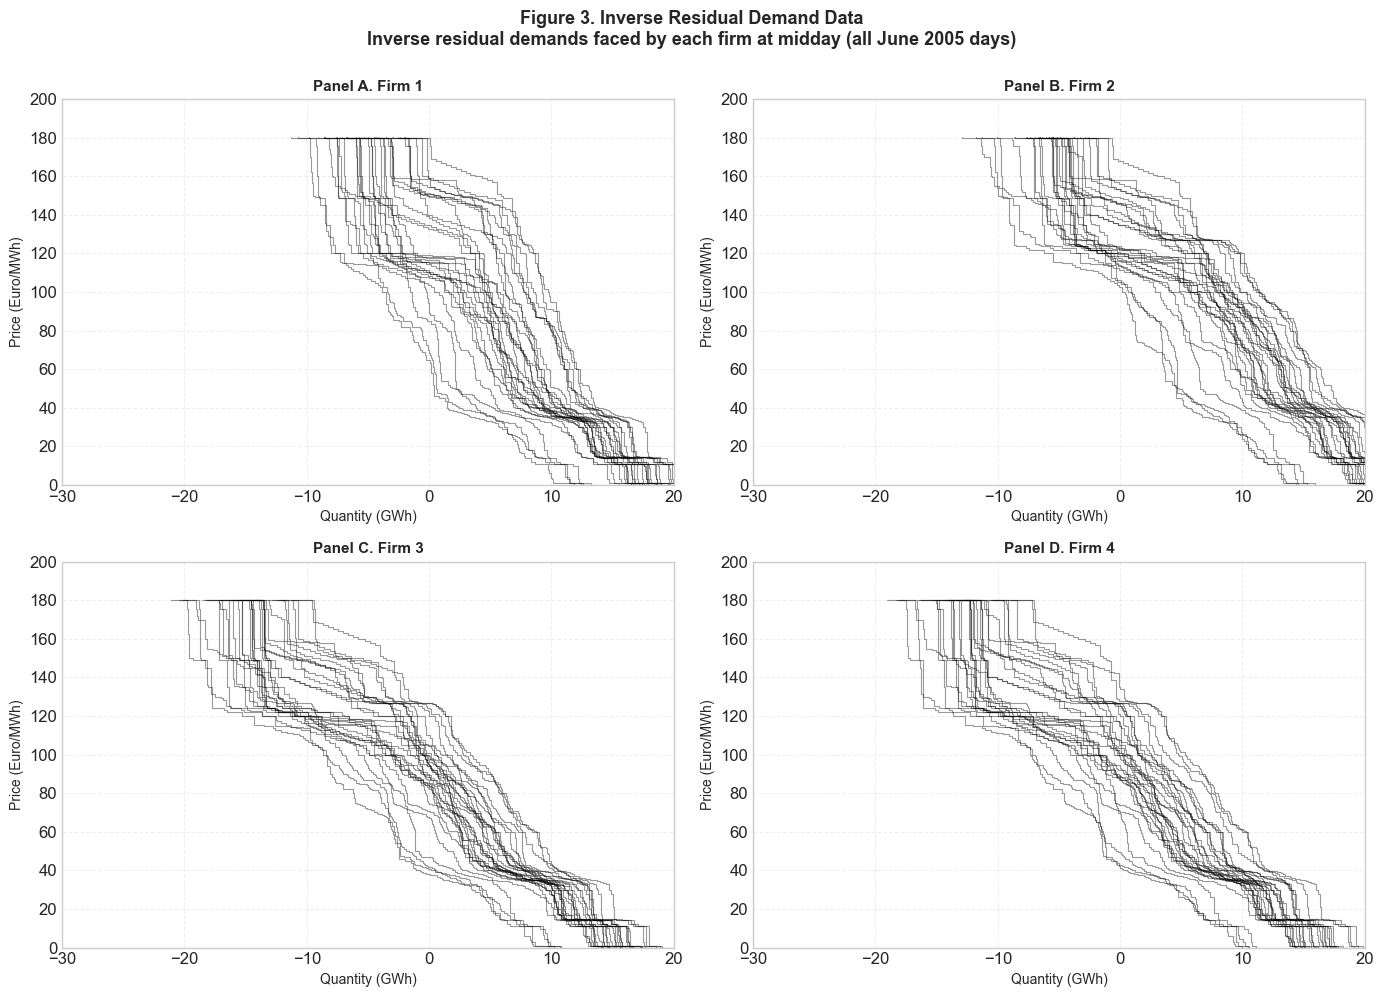


Figure saved to /Users/svenhominal/Desktop/CODE CLEAN ECONOMICS/112855-V1 (1)/20130186_data/figures/figure3_inverse_residual_demands.png

Note: Inverse residual demand curves show the price at which each firm can
sell different quantities. Negative quantities indicate the firm is a net buyer.
The curves are downward-sloping step functions characteristic of bid-based markets.
All 30 June 2005 days are shown.


In [16]:
# =============================================================================
# FIGURE 3: Sample Inverse Residual Demands at Midday
# Replicating Figure 3 from Fabra & Reguant (2014)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("\n" + "=" * 100)
print("FIGURE 3: Inverse Residual Demand at Midday (Hour 12)")
print("Fabra & Reguant (2014), American Economic Review")
print("=" * 100)

def compute_inverse_residual_demand_correct(df_hour, firm_code):
    """
    Compute inverse residual demand for a specific firm at a given hour.
    
    Inverse residual demand = Total demand - Supply from other firms
    
    At each price level p:
    - Total demand = All demand bids willing to pay >= p
    - Other supply = All supply offers from other firms at price <= p
    - Residual demand = Total demand - Other supply
    
    Returns quantity in GWh (can be negative if net seller).
    """
    # Separate supply and demand
    supply = df_hour[df_hour['direction'] == 2].copy()  # direction=2 is supply
    demand = df_hour[df_hour['direction'] == 1].copy()  # direction=1 is demand
    
    # Get focal firm's bids and other firms' bids
    focal_firm_supply = supply[supply['firm_code'] == firm_code].copy()
    other_firms_supply = supply[supply['firm_code'] != firm_code].copy()
    
    # Create price grid from 0 to 180 (to ensure lines extend fully)
    min_price = 0
    max_price = 180  # Fixed to 180 Euro/MWh
    
    # Get all unique prices to create step function
    all_prices = np.sort(np.unique(np.concatenate([
        [min_price, max_price],
        supply['price'].values, 
        demand['price'].values
    ])))
    
    # For each price, compute residual demand
    rd_points = []
    
    for p in all_prices:
        # Total demand at this price (sum of all demand willing to pay >= p)
        total_demand = demand[demand['price'] >= p]['mwh'].sum()
        
        # Supply from other firms at prices <= p (what they're offering below or at this price)
        other_supply = other_firms_supply[other_firms_supply['price'] <= p]['mwh'].sum()
        
        # Residual demand = what's left for focal firm
        # Positive means firm can sell, negative means net buyer
        residual = total_demand - other_supply
        
        rd_points.append((residual / 1000, p))  # Convert MWh to GWh
    
    # Convert to array and sort by quantity (x-axis)
    rd_points = np.array(rd_points)
    
    return rd_points

# Load ALL June 2005 days (30 days)
data_files = sorted(glob.glob(f'{MATLAB_DATA}/data_*.csv'))
selected_files = data_files[:30]  # All 30 June days

print(f"\nPlotting ALL {len(selected_files)} June 2005 days at midday (hour 12):")

# Create 2x2 subplots for the 4 firms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

firm_labels = {
    1: 'Panel A. Firm 1',
    2: 'Panel B. Firm 2', 
    3: 'Panel C. Firm 3',
    4: 'Panel D. Firm 4'
}

for firm_idx, firm_code in enumerate([1, 2, 3, 4]):
    ax = axes[firm_idx]
    
    for file_idx, file_path in enumerate(selected_files):
        date = os.path.basename(file_path).replace('data_', '').replace('.csv', '')
        df = pd.read_csv(file_path)
        
        # Filter to hour 12 (midday/noon) as in the paper
        df_hour = df[df['hour'] == 12].copy()
        
        if len(df_hour) == 0:
            continue
        
        # Compute inverse residual demand
        rd_curve = compute_inverse_residual_demand_correct(df_hour, firm_code)
        
        # Sort by price for proper plotting
        rd_curve = rd_curve[np.argsort(rd_curve[:, 1])]
        
        # Plot as step function (characteristic of bid-based markets)
        ax.step(rd_curve[:, 0], rd_curve[:, 1], where='post',
                color='black', alpha=0.4, linewidth=0.8)
    
    # Set axis limits: x from -30 to 20 GWh, y from 0 to 200 Euro/MWh
    ax.set_xlim(-30, 20)
    ax.set_ylim(0, 200)
    ax.set_yticks(np.arange(0, 201, 20))  # Y-axis ticks every 20
    ax.set_xlabel('Quantity (GWh)', fontsize=10)
    ax.set_ylabel('Price (Euro/MWh)', fontsize=10)
    ax.set_title(firm_labels[firm_code], fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

# Overall title
plt.suptitle('Figure 3. Inverse Residual Demand Data\nInverse residual demands faced by each firm at midday (all June 2005 days)', 
             fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(f'{FIGURES}/figure3_inverse_residual_demands.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to {FIGURES}/figure3_inverse_residual_demands.png")
print("\nNote: Inverse residual demand curves show the price at which each firm can")
print("sell different quantities. Negative quantities indicate the firm is a net buyer.")
print("The curves are downward-sloping step functions characteristic of bid-based markets.")
print("All 30 June 2005 days are shown.")
print("=" * 100)